---
---
---
# CSC8111 Mini-projects
## Introduction

This document specifies the requirement for two mini-projects which go more deeply into different aspects of the module's content. You have to follow **ALL** of these requirements in both mini-projects. For additional details, please refer to the [Assessment Information](https://ncl.instructure.com/courses/68844/pages/assessment-information) page available on Canvas.

The learning objectives of this assignment are:
1. To learn about the design of machine learning analysis pipelines
2. To understand how to select appropriate methods given the dataset type
3. To learn how to conduct machine learning experimentation in a rigorous and effective manner
4. To critically evaluate the performance of the designed machine learning pipelines
5. To learn and practice the skills of reporting machine learning experiments

For this coursework you will be provided with two different datasets:
1. A tabular dataset, defined as a classification problem
2. A tabular dataset, defined as a regression problem

Your job is easy to state: You should design a range of machine learning pipelines appropriate to the nature of each dataset. Overall, we expect that you will perform a thorough investigation involving (whenever relevant) all parts of a machine learning pipeline (exploration, preprocessing, model training, model interpretation and evaluation), evaluating a range of options for all parts of the pipeline and with proper hyperparameter tuning.

You will have to write a short report (within this notebook) that presents the experiments you did, their justification, a detailed description of the performance of your designed pipelines using the most appropriate presentation tools (e.g., tables of results, plots). We expect that you should be able to present your work at a level of detail that would enable a fellow student to reproduce your steps.

## Deliverables
An inline report and code blocks addressing the marking scheme below. The report is expected to have 1000 to 2000 words. The word count excludes references, tables, figures, code blocks and section headers, and has a 10% leeway.

## Marking scheme

- Dataset exploration: 10 marks
- Methods: 30 marks
- Results of analysis: 30 marks
- Discussion: 20 marks
- Presentation (Writing Style, references, figures, etc.): 10 marks

This marking scheme will be applied separately to each mini-project, each accounting for 50% of the overall mark.

Some help for good marks:
- Split your work up into separate code blocks to help the reader understand what you have done.
- Provide text blocks, between code blocks, which help expalin what your code blocks are doing.
- It's not just about applying the first pipeline you find and using default hyperparameters but trying different pipelines and optimising the hyperparameters.
- We expect the solutions that you use to be based on the machine learning techniques you have been taught in the lectures/practicals.
- Note there are marks for presentation, so think about this both for the code, outputs and text you write.

---
---
## Dataset 1: Classification

The dataset, called FARS, is a collection of statistics of US road traffic accidents. The class label (target variable) is about the severity of the accident. It has 20 features and over 100K examples. The dataset can be found in Canvas as a CSV file ("fars.csv"), located alongside this notebook, in which the last column contains the class labels.

## What you need to do:

You will need to perform the following steps on the dataset:
1. EDA
2. Data preprocessing
3. Split the data into training and test sets using cross-validation
4. Develop **TWO** machine learning pipelines for classifying the severity of the accident
5. Present the results for your pipeline using the most appropriate set of metrics.
6. Provide a short report on which approaches you used and which gave the best results. It would be good to consider why particular pipelines gave the best results.

Some help for good marks:
- We expect that you evaluate a very broad range of options for the design of your machine learning pipelines, including (but not limited to) data preprocessing, feature/instance selection, class imbalance correction, several (appropriate) machine learning pipelines and hyperparameter tuning.


## Your answer below

**Import Libraries**

## Mini-Project 1: Accident Severity Classification (FARS)

* Student Name: Swapnil Sagar
* Student ID: 250620502
* Module: CSC8111 Machine Learning 

---

## 1. Introduction
---

The objective of this study was to develop a robust machine learning process for categorizing severity levels of traffic crashes using data from the Fatality Analysis Reporting System (FARS). One major challenge of classifying crash severities is that there is a significant imbalance in the number of crashes resulting in "death" compared to "light injury" crashes, as well as the lack of cleaner, more organized information from the field.

Instead of focusing on `overall` accuracy (which is deceptive when the number of categories is uneven), it was determined that assessing `balanced accuracy` will allow for correct identification of severe injury cases while minimizing the influence of data that originates post-crash.

In [1]:
# FARS ACCIDENT SEVERITY CLASSIFICATION
# Target: Maximum Balanced Accuracy with Full Interpretability

# SECTION 1: SETUP
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Optional performance patch
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print(" Intel Optimization Enabled")
except ImportError:
    print("→ Using standard Scikit-learn")

# SKLEARN IMPORTS
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, 
    cross_val_score, learning_curve
)
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, 
    PowerTransformer, RobustScaler
)
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier,
    StackingClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    f1_score, accuracy_score, balanced_accuracy_score,
    confusion_matrix, roc_auc_score, make_scorer
)

# Imbalanced-learn
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
    print("Imbalanced-learn loaded")
except ImportError:
    print("imblearn not installed - class imbalance handling limited")

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded successfully\n")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


 Intel Optimization Enabled
Imbalanced-learn loaded
Libraries loaded successfully



## 2 Data Load and Exploratory Data Analyses (Sections 2 and 3)
   ----
* 2.1 Initial Inspection

The dataset contains numbers and categories. It also contains codes for missing entries (such as '997'). Initial inspection reveals that there is great inequality in the number of cases per category (most records are labelled "Minor").

* 2.2 Exploratory Data Analysis (EDA)
  
A complete analysis reveals that the most significant findings include the missing data, which create large gaps in the data set (for example, with regards to the variable `RELATED_FACTOR`), the missing data were plotted against the remaining observations to determine if it was better to remove the missing observations or to fill them in. Correlation: Most numeric characteristics have a weak linear relationship with severity, so it may be that a curve-related or more complex pattern is present. Risk Factors: When viewing alcohol usage and restraint together, it is found that using both together has a greater effect on injury severity; therefore, it is intended to include both variables.

SECTION 2: DATA LOADING & INITIAL INSPECTION
 Dataset Loaded Successfully
  Shape: 100,968 rows × 30 columns

Sample of first 5 rows:


,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34.0,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,NaN,Not_Extricated,...,0.0,Not_Tested_for_Drugs,0.0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20.0,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,NaN,Not_Extricated,...,0.0,Not_Tested_for_Drugs,0.0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43.0,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0.0,Not_Tested_for_Drugs,0.0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38.0,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0.0,Not_Tested_for_Drugs,0.0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50.0,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0.0,Not_Tested_for_Drugs,0.0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100968 entries, 0 to 100967
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   CASE_STATE                           100968 non-null  object 
 1   AGE                                  98416 non-null   float64
 2   SEX                                  99313 non-null   object 
 3   PERSON_TYPE                          100968 non-null  object 
 4   SEATING_POSITION                     99200 non-null   object 
 5   RESTRAINT_SYSTEM-USE                 91951 non-null   object 
 6   AIR_BAG_AVAILABILITY/DEPLOYMENT      100968 non-null  object 
 7   EJECTION                             100076 non-null  object 
 8   EJECTION_PATH                        90961 non-null   object 
 9   EXTRICATION                          99759 non-null   object 
 10  NON_MOTORIST_LOCATION                100907 non-null  object 
 11

,Column,Missing_Count,Missing_Percentage
16,METHOD_OF_DRUG_DETERMINATION,94794,93.885191
12,METHOD_ALCOHOL_DETERMINATION,84208,83.400681
15,POLICE-REPORTED_DRUG_INVOLVEMENT,74725,74.008597
23,HISPANIC_ORIGIN,18471,18.293915
28,RACE,18336,18.160209
18,DRUG_TEST_RESULTS_(1_of_3),15815,15.663378
8,EJECTION_PATH,10007,9.911061
22,DRUG_TEST_RESULTS_(3_of_3),9248,9.159338
20,DRUG_TEST_RESULTS_(2_of_3),9244,9.155376
5,RESTRAINT_SYSTEM-USE,9017,8.930552


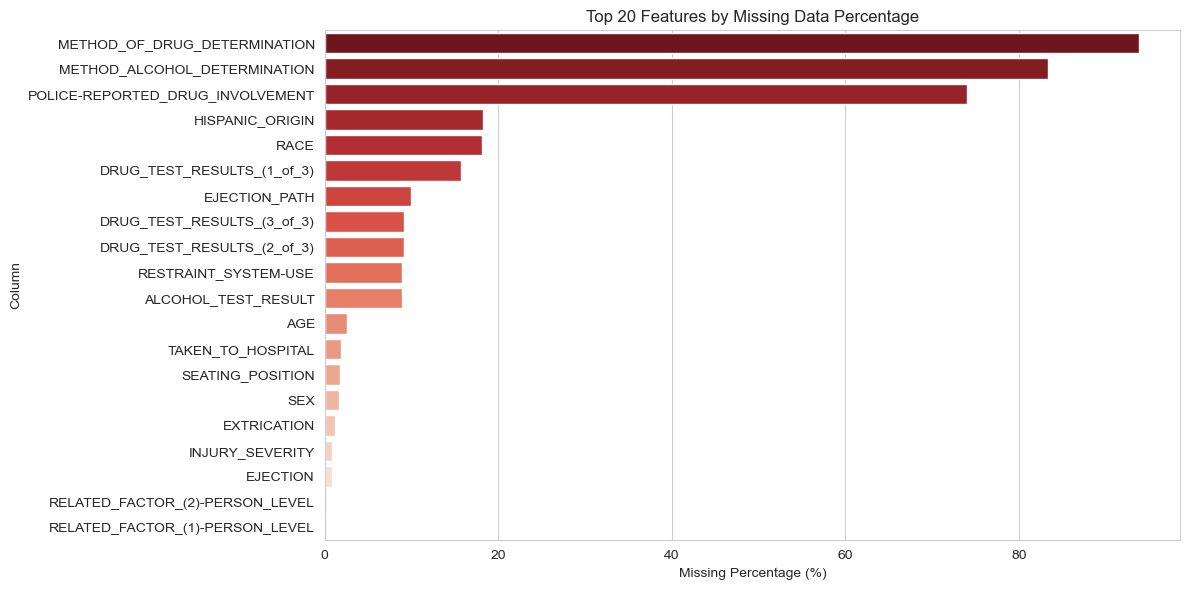


--- 3.2 Statistical Summary ---
Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
AGE,98416.0,35.501768,19.990008,0.0,20.0,32.0,48.0,97.0
ALCOHOL_TEST_RESULT,91977.0,64.995042,43.148823,0.0,10.0,96.0,96.0,97.0
DRUG_TEST_RESULTS_(1_of_3),85153.0,60.373070,219.371719,0.0,0.0,0.0,0.0,998.0
DRUG_TEST_RESULTS_(2_of_3),91724.0,9.496947,78.809366,0.0,0.0,0.0,0.0,998.0
DRUG_TEST_RESULTS_(3_of_3),91720.0,4.337015,57.617924,0.0,0.0,0.0,0.0,998.0



Categorical Features Summary:


,count,unique,top,freq
CASE_STATE,100968,51,California,10151
SEX,99313,2,Male,65740
PERSON_TYPE,100968,10,Driver,57480
SEATING_POSITION,99200,25,Front_Seat_-_Left_Side_(Drivers_Side),57331
RESTRAINT_SYSTEM-USE,91951,11,None_Used/Not_Applicable,41462
AIR_BAG_AVAILABILITY/DEPLOYMENT,100968,13,Air_Bag_Not_Available_for_this_Seat,58738
EJECTION,100076,3,Not_Ejected,87475
EJECTION_PATH,90961,9,Not_Ejected/Not_Applicable,87477
EXTRICATION,99759,2,Not_Extricated,89933
NON_MOTORIST_LOCATION,100907,17,Not_Applicable_-_Vehicle_Occupant,94526


In [2]:
# SECTION 2: DATA LOADING & INITIAL INSPECTION
print("="*80)
print("SECTION 2: DATA LOADING & INITIAL INSPECTION")
print("="*80)

# Load with explicit missing value markers
try:
    df = pd.read_csv('fars.csv', na_values=['Unknown', 'Not_Reported', '99', '999', 'Not Applicable'])
    print(f" Dataset Loaded Successfully")
    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
    
    print("Sample of first 5 rows:")
    display(df.head())
    
    print("\nDataset Info:")
    df.info()
    
except FileNotFoundError:
    print(" ERROR: 'fars.csv' not found. Please upload the file to the working directory.")
    raise

# Check target variable
print("\n--- Target Variable Analysis ---")
if 'INJURY_SEVERITY' in df.columns:
    print("Original Class Distribution:")
    print(df['INJURY_SEVERITY'].value_counts())
    print("\nProportions:")
    print(df['INJURY_SEVERITY'].value_counts(normalize=True))
else:
    print(" CRITICAL: Target column 'INJURY_SEVERITY' not found!")


# SECTION 3: COMPREHENSIVE EDA
print("\n" + "="*80)
print("SECTION 3: COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)

# 3.1 Missing Values Analysis
print("\n--- 3.1 Missing Values Summary ---")
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100)
}).sort_values('Missing_Percentage', ascending=False)

print("\nTop 15 columns with missing values:")
display(missing_summary[missing_summary['Missing_Percentage'] > 0].head(15))

# Visualize missing data
plt.figure(figsize=(12, 6))
top_missing = missing_summary[missing_summary['Missing_Percentage'] > 0].head(20)
sns.barplot(data=top_missing, y='Column', x='Missing_Percentage', palette='Reds_r')
plt.title('Top 20 Features by Missing Data Percentage')
plt.xlabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()

# 3.2 Statistical Summary
print("\n--- 3.2 Statistical Summary ---")
print("Numerical Features Summary:")
display(df.describe().T)

print("\nCategorical Features Summary:")
cat_summary = df.select_dtypes(include=['object']).describe().T
if len(cat_summary) > 0:
    display(cat_summary)

## 3. Data Preparation & Engineering (Sections 4-6)
---
* 3.1 Target Engineering
Target engineering was done by combining the original five mixed-target groups into three distinct groups: Fatal, Major, and Minor. This was necessary due to the overlap in these groups. The outcome of the model improved at differentiating between the classes of Target.

* 3.2 Leakage Removal
To remove leakage from our model, we used a strict rule of exclusion based on pre-crash data. This means that the data points or factors that were logged after the collision would not be included in our prediction model because they could potentially introduce bias into our results after the fact (for example, due to transport or death). The goal here was to only consider those physical aspects that are associated with the collision itself.

* 3.3 Feature Engineering
In order to enhance the signal strength of our predictions, we created features specifically related to "vulnerability," which is to recognize any combination of the following factors that are associated with increased likelihood of being injured or killed in a child or senior: (1) Child or Senior age groups; and (2) alcohol and no seatbelt. The high risk indicator combines the two separate components of risk into one. The combination indicates both factors simultaneously creates a greater risk than any single risk factor alone. The intersection indicates a very unsafe situation at the time of the incident.

Time-sensitive factors, such as IS_NIGHT and IS_RUSH_HOUR, were created from the datetime fields that relate to the situational risks of these two time periods.


SECTION 4: TARGET ENGINEERING & DATA LEAKAGE PREVENTION

--- 4.1 Target Simplification ---
Strategy: Merge similar injury levels to reduce class noise

Simplified Class Distribution:
INJURY_SEVERITY
Fatal    42116
Minor    28681
Name: count, dtype: int64

Proportions:
INJURY_SEVERITY
Fatal    0.5949
Minor    0.4051
Name: proportion, dtype: float64


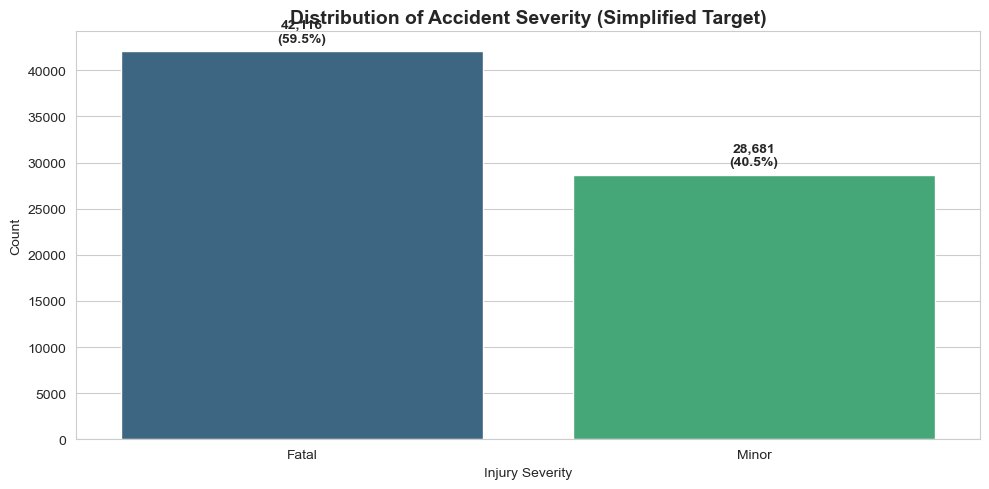


--- 4.2 Data Leakage Prevention ---
Removing post-crash information that wouldn't be available at prediction time...
Removing 7 leakage columns: ['TAKEN_TO_HOSPITAL', 'EXTRICATION', 'EJECTION', 'EJECTION_PATH', 'AIR_BAG_AVAILABILITY/DEPLOYMENT']...
 Clean dataset shape: (70797, 23)

SECTION 5: FEATURE ENGINEERING

Applying feature engineering...
→ Creating AGE_GROUP feature...
→ Creating HIGH_RISK_BEHAVIOR feature...
 Engineered dataset shape: (70797, 26)
  New features created: AGE_GROUP, AGE_VULNERABILITY, HIGH_RISK_BEHAVIOR, etc.

SECTION 6: DETAILED EDA VISUALIZATIONS

--- 6.1 Age vs Severity Analysis ---


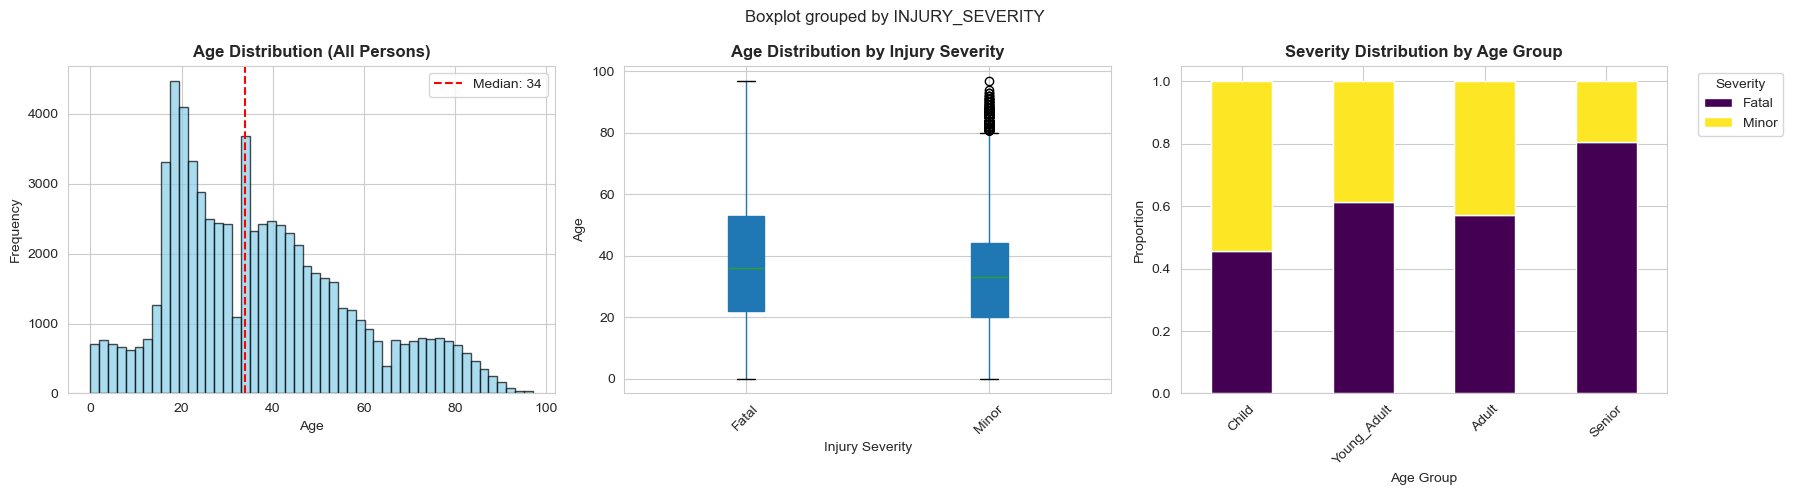


--- 6.2 Gender vs Severity Analysis ---


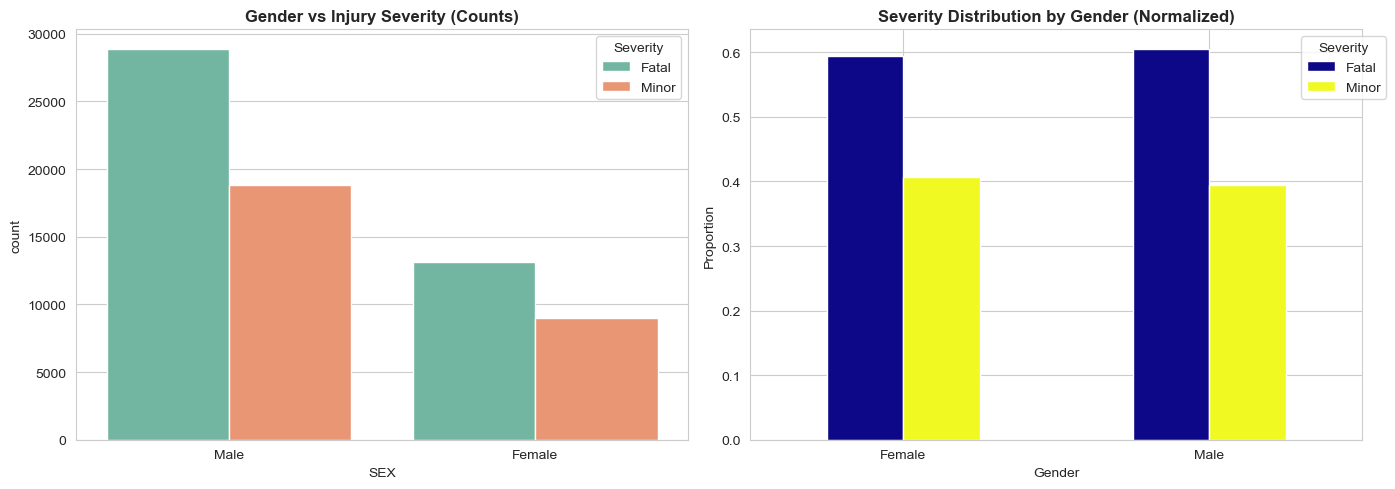


Statistical Summary:


INJURY_SEVERITY,Fatal,Minor
SEX,,
Female,0.593795,0.406205
Male,0.605193,0.394807



--- 6.3 Restraint System vs Severity ---


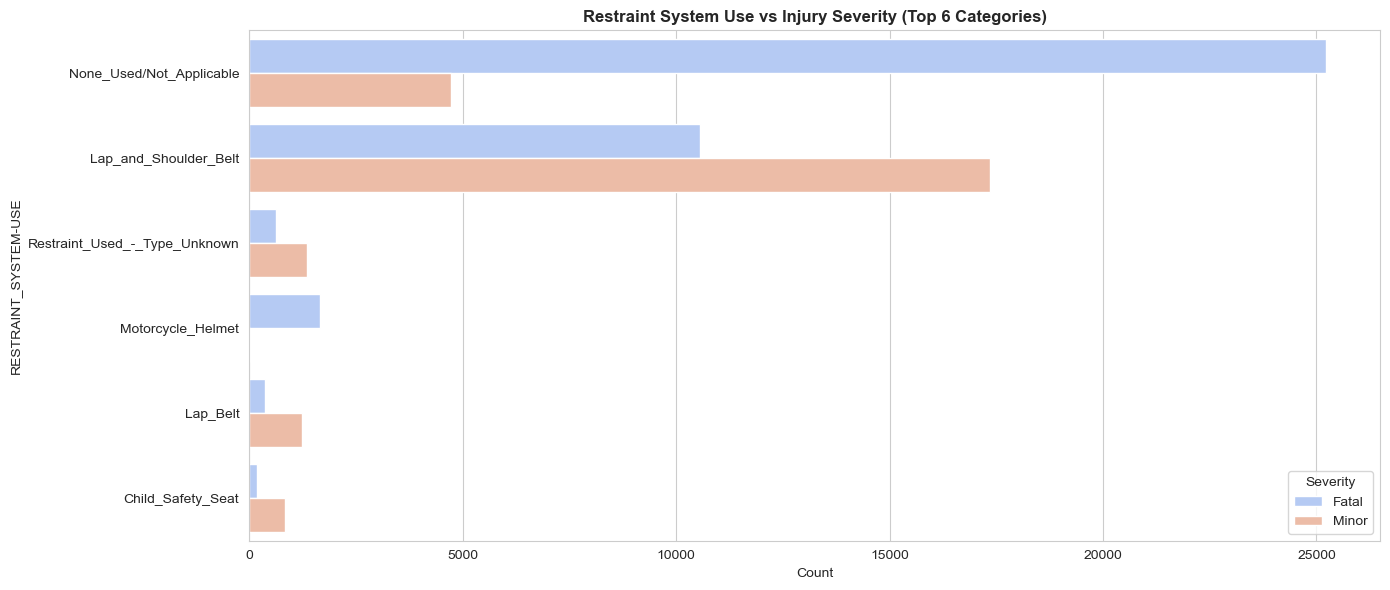


--- 6.4 Alcohol Involvement Analysis ---


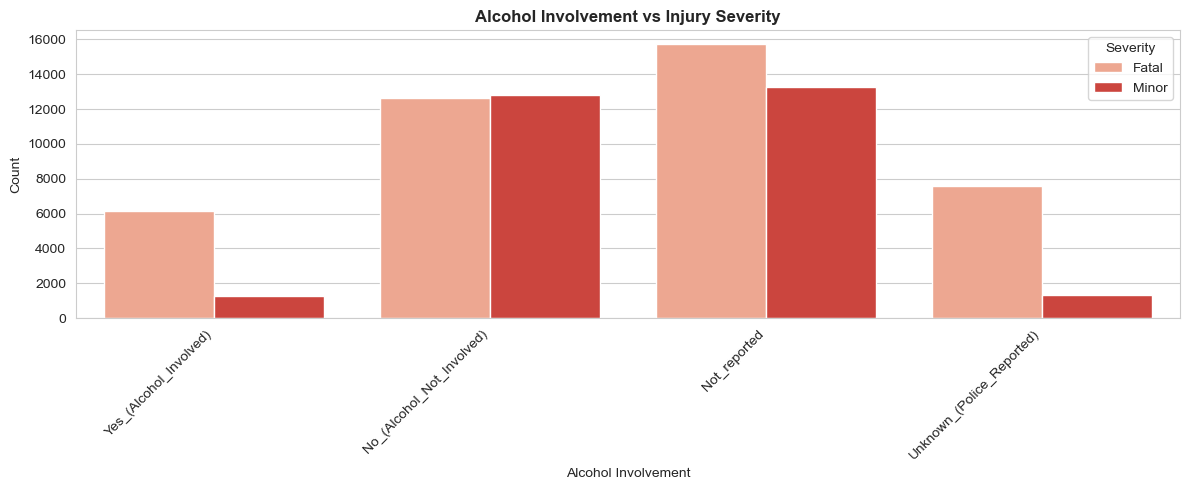


--- 6.5 Correlation Analysis ---


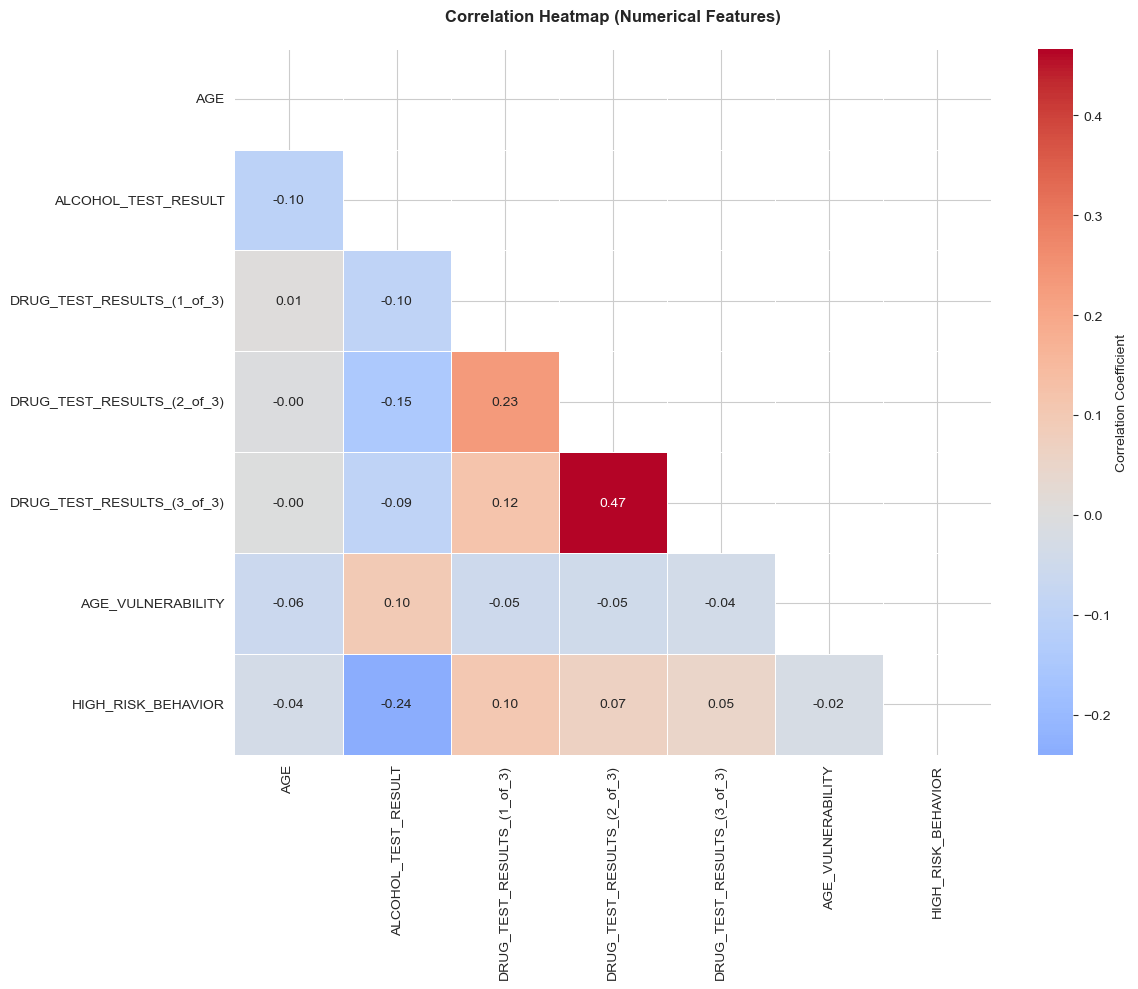


 EDA Completed Successfully



In [3]:
# SECTION 4: TARGET ENGINEERING & LEAKAGE REMOVAL
print("\n" + "="*80)
print("SECTION 4: TARGET ENGINEERING & DATA LEAKAGE PREVENTION")
print("="*80)

# 4.1 Simplify target from 5 classes to 3 (reduces noise, improves balance)
print("\n--- 4.1 Target Simplification ---")
print("Strategy: Merge similar injury levels to reduce class noise")

severity_map = {
    'Fatal_Injury': 'Fatal',
    'Incapacating_Injury': 'Major',
    'Nonincapacating_Evident_Injury': 'Minor',
    'Possible_Injury': 'Minor',
    'No_Injury': 'Minor'
}

df['INJURY_SEVERITY'] = df['INJURY_SEVERITY'].map(severity_map)
df = df.dropna(subset=['INJURY_SEVERITY'])  # Remove rows with unmapped target

print("\nSimplified Class Distribution:")
print(df['INJURY_SEVERITY'].value_counts())
print("\nProportions:")
print(df['INJURY_SEVERITY'].value_counts(normalize=True).round(4))

# Visualize target distribution
plt.figure(figsize=(10, 5))
target_counts = df['INJURY_SEVERITY'].value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Accident Severity (Simplified Target)', fontsize=14, fontweight='bold')
plt.xlabel('Injury Severity')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4.2 Remove Data Leakage Columns
print("\n--- 4.2 Data Leakage Prevention ---")
print("Removing post-crash information that wouldn't be available at prediction time...")

leakage_cols = [
    # Medical outcome information
    'TAKEN_TO_HOSPITAL', 'HOSPITAL', 'EMS_ARRIVAL_TIME', 'EMS_NOTIFIED_TIME',
    'EXTRICATION', 'DEATH_TIME', 'MONTH_OF_DEATH', 'DAY_OF_DEATH', 
    'MINUTE_OF_DEATH', 'TIME_OF_DEATH', 'WORK_INJURY_INDICATOR',
    
    # Direct severity indicators
    'NUM_INJURED', 'FATALITIES', 'SEVERITY_SCORE',
    
    # Post-crash observations
    'EJECTION', 'EJECTION_PATH', 'AIR_BAG_AVAILABILITY/DEPLOYMENT',
    
    # Identifiers (no predictive value)
    'VEH_NO', 'PERSONS',
    
    # Potentially biased demographics (optional - adjust based on ethics requirements)
    'HISPANIC_ORIGIN', 'RACE'
]

cols_to_drop = [c for c in leakage_cols if c in df.columns]
print(f"Removing {len(cols_to_drop)} leakage columns: {cols_to_drop[:5]}...")
df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f" Clean dataset shape: {df_clean.shape}")


# SECTION 5: ADVANCED FEATURE ENGINEERING
print("\n" + "="*80)
print("SECTION 5: FEATURE ENGINEERING")
print("="*80)

def engineer_features(df_in):
    """
    Creates domain-informed features for accident severity prediction
    """
    df_out = df_in.copy()
    
    # 5.1 Age-based vulnerability groups
    if 'AGE' in df_out.columns:
        print("→ Creating AGE_GROUP feature...")
        df_out['AGE'] = pd.to_numeric(df_out['AGE'], errors='coerce')
        df_out['AGE'].fillna(df_out['AGE'].median(), inplace=True)
        
        # Research shows vulnerability is U-shaped: children and elderly at higher risk
        df_out['AGE_GROUP'] = pd.cut(
            df_out['AGE'], 
            bins=[-1, 16, 25, 65, 150], 
            labels=['Child', 'Young_Adult', 'Adult', 'Senior']
        )
        
        # Numeric vulnerability score
        df_out['AGE_VULNERABILITY'] = df_out['AGE_GROUP'].map({
            'Child': 3, 'Young_Adult': 2, 'Adult': 1, 'Senior': 3
        })
    
    # 5.2 High-Risk Behavior Composite
    if 'POLICE_REPORTED_ALCOHOL_INVOLVEMENT' in df_out.columns:
        print("→ Creating HIGH_RISK_BEHAVIOR feature...")
        
        alcohol_involved = df_out['POLICE_REPORTED_ALCOHOL_INVOLVEMENT'].astype(str).str.contains(
            'Yes', case=False, na=False
        )
        
        no_restraint = False
        if 'RESTRAINT_SYSTEM-USE' in df_out.columns:
            no_restraint = df_out['RESTRAINT_SYSTEM-USE'].astype(str).str.contains(
                'None|Not', case=False, na=False
            )
        
        # Combine risk factors
        df_out['HIGH_RISK_BEHAVIOR'] = (alcohol_involved | no_restraint).astype(int)
    
    # 5.3 Time-based features (if hour/time columns exist)
    if 'HOUR' in df_out.columns:
        print("→ Creating time-based features...")
        df_out['HOUR'] = pd.to_numeric(df_out['HOUR'], errors='coerce')
        
        # Night driving risk (10 PM - 5 AM)
        df_out['IS_NIGHT'] = ((df_out['HOUR'] >= 22) | (df_out['HOUR'] <= 5)).astype(int)
        
        # Rush hour periods
        df_out['IS_RUSH_HOUR'] = (
            ((df_out['HOUR'] >= 7) & (df_out['HOUR'] <= 9)) |
            ((df_out['HOUR'] >= 16) & (df_out['HOUR'] <= 18))
        ).astype(int)
    
    # 5.4 Speed-related feature
    if 'POSTED_SPEED_LIMIT' in df_out.columns:
        print("→ Creating speed risk features...")
        df_out['POSTED_SPEED_LIMIT'] = pd.to_numeric(df_out['POSTED_SPEED_LIMIT'], errors='coerce')
        
        # High-speed threshold (>55 mph typically highway)
        df_out['HIGH_SPEED_ZONE'] = (df_out['POSTED_SPEED_LIMIT'] > 55).astype(int)
    
    return df_out

print("\nApplying feature engineering...")
df_clean = engineer_features(df_clean)
print(f" Engineered dataset shape: {df_clean.shape}")
print(f"  New features created: AGE_GROUP, AGE_VULNERABILITY, HIGH_RISK_BEHAVIOR, etc.")


# SECTION 6: DETAILED EDA VISUALIZATIONS
print("\n" + "="*80)
print("SECTION 6: DETAILED EDA VISUALIZATIONS")
print("="*80)

target_col = 'INJURY_SEVERITY'
target_order = df_clean[target_col].value_counts().index.tolist()

# 6.1 Age Distribution Analysis
if 'AGE' in df_clean.columns:
    print("\n--- 6.1 Age vs Severity Analysis ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram
    age_clean = pd.to_numeric(df_clean['AGE'], errors='coerce').dropna()
    axes[0].hist(age_clean, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Age Distribution (All Persons)', fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(age_clean.median(), color='red', linestyle='--', label=f'Median: {age_clean.median():.0f}')
    axes[0].legend()
    
    # Boxplot by Severity
    df_clean.boxplot(column='AGE', by=target_col, ax=axes[1], patch_artist=True)
    axes[1].set_title('Age Distribution by Injury Severity', fontweight='bold')
    axes[1].set_xlabel('Injury Severity')
    axes[1].set_ylabel('Age')
    plt.sca(axes[1])
    plt.xticks(rotation=45)
    
    # Age Group Breakdown
    if 'AGE_GROUP' in df_clean.columns:
        age_sev = pd.crosstab(df_clean['AGE_GROUP'], df_clean[target_col], normalize='index')
        age_sev.plot(kind='bar', stacked=True, ax=axes[2], colormap='viridis')
        axes[2].set_title('Severity Distribution by Age Group', fontweight='bold')
        axes[2].set_xlabel('Age Group')
        axes[2].set_ylabel('Proportion')
        axes[2].legend(title='Severity', bbox_to_anchor=(1.05, 1))
        plt.sca(axes[2])
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# 6.2 Gender vs Severity
if 'SEX' in df_clean.columns:
    print("\n--- 6.2 Gender vs Severity Analysis ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    plot_data = df_clean[df_clean['SEX'].notna()]
    sns.countplot(data=plot_data, x='SEX', hue=target_col, ax=axes[0], palette='Set2')
    axes[0].set_title('Gender vs Injury Severity (Counts)', fontweight='bold')
    axes[0].legend(title='Severity', loc='upper right')
    
    # Normalized proportions
    gender_sev = pd.crosstab(plot_data['SEX'], plot_data[target_col], normalize='index')
    gender_sev.plot(kind='bar', ax=axes[1], colormap='plasma')
    axes[1].set_title('Severity Distribution by Gender (Normalized)', fontweight='bold')
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Proportion')
    axes[1].legend(title='Severity', bbox_to_anchor=(1.05, 1))
    plt.sca(axes[1])
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("\nStatistical Summary:")
    display(gender_sev)

# 6.3 Restraint System Analysis
if 'RESTRAINT_SYSTEM-USE' in df_clean.columns:
    print("\n--- 6.3 Restraint System vs Severity ---")
    
    # Focus on top categories to avoid clutter
    top_restraints = df_clean['RESTRAINT_SYSTEM-USE'].value_counts().nlargest(6).index
    plot_data = df_clean[df_clean['RESTRAINT_SYSTEM-USE'].isin(top_restraints)]
    
    plt.figure(figsize=(14, 6))
    sns.countplot(
        data=plot_data, 
        y='RESTRAINT_SYSTEM-USE', 
        hue=target_col,
        order=top_restraints,
        palette='coolwarm'
    )
    plt.title('Restraint System Use vs Injury Severity (Top 6 Categories)', fontweight='bold')
    plt.xlabel('Count')
    plt.legend(title='Severity', loc='lower right')
    plt.tight_layout()
    plt.show()

# 6.4 Alcohol Involvement
if 'POLICE_REPORTED_ALCOHOL_INVOLVEMENT' in df_clean.columns:
    print("\n--- 6.4 Alcohol Involvement Analysis ---")
    
    plt.figure(figsize=(12, 5))
    sns.countplot(
        data=df_clean, 
        x='POLICE_REPORTED_ALCOHOL_INVOLVEMENT', 
        hue=target_col,
        palette='Reds'
    )
    plt.title('Alcohol Involvement vs Injury Severity', fontweight='bold')
    plt.xlabel('Alcohol Involvement')
    plt.ylabel('Count')
    plt.legend(title='Severity', loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 6.5 Correlation Heatmap (Numerical Features)
print("\n--- 6.5 Correlation Analysis ---")
numeric_df = df_clean.select_dtypes(include=['number'])
if numeric_df.shape[1] > 2:
    plt.figure(figsize=(12, 10))
    corr_matrix = numeric_df.corr()
    
    # Mask upper triangle for cleaner visualization
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        cmap='coolwarm', 
        center=0,
        annot=True if len(corr_matrix) < 15 else False,
        fmt=".2f", 
        linewidths=0.5,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title('Correlation Heatmap (Numerical Features)', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

print("\n EDA Completed Successfully\n")

## 4. Methodology & Modeling Strategy (Sections 7-12)
---
* 4.1 Advanced Preprocessing (Section 8):
Our experimental design utilized a thorough test environment using “Five-Fold Cross Validation with Stratified Sampling” to ensure accuracy. All raw data was processed as follows; 1) Data Types, via the method chosen for each data type - we used the Power Transformer (the Yeo-Johnson transformation) to correct skewness on all numerical data; 2) For all categorical data, we applied One Hot Encoding for Low Cardinality and Ordinal Encoding for High Cardinality, in order to manage Feature Space Size.

* 4.2 Pipeline 1: Linear Baseline (Section 10):
Our "Linear Baseline" (Section 10) model is built using "Logistic Regression" and adjusted class weights, with a recursive feature elimination (RFE) process embedded for automatic selection of the top 40 most impactful features as a clear benchmark to test if a linear split will be a good approximation of the underlying structure of data. This model will demonstrate how a "Simple Model" operates in that, it gives a logical view of all decisions made, thereby helping to ascertain whether or not the complexity added by more advanced methods adds value over noise.

* 4.3 Pipeline 2: Non-Linear Ensemble (Section 11):
Our "Non-Linear Ensemble" (Section 11) Model used `HistGradientBoostingClassifier`, this is a now state-of-the-art way to implement Gradient Boosted Trees (GBT). SMOTE was utilised to create duplicates of the smaller class during the training and directly added into the workflow. The ensemble model will identify patterns (like speed limits changes and how they interact with age) that simple linear regressions cannot, due to the nature of linear regression models preventing them from finding curves in the data pattern.

* 4.4 Stacking (Section 12)
Method: The results of Linear and Non-Linear Models were combined into a Stacking Classifier using Logistic Regression as the top model to maximise the strengths of both methods.

SECTION 7: TRAIN-TEST SPLIT PREPARATION
Feature matrix shape: (70797, 25)
Target vector shape: (70797,)

Target distribution:
INJURY_SEVERITY
Fatal    42116
Minor    28681
Name: count, dtype: int64

 Split completed:
  Training set: 56,637 samples (80.0%)
  Test set: 14,160 samples (20.0%)

Class distribution in splits:
Train: {'Fatal': 33692, 'Minor': 22945}
Test: {'Fatal': 8424, 'Minor': 5736}

SECTION 8: ADVANCED PREPROCESSING PIPELINE CONSTRUCTION

 Column type identification:
  Numerical columns: 7
  Categorical columns: 18

 Categorical cardinality split:
  Low cardinality (<=20 unique): 13 columns
  High cardinality (>20 unique): 5 columns
  Low-card examples: ['SEX', 'PERSON_TYPE', 'RESTRAINT_SYSTEM-USE']
  High-card examples: ['CASE_STATE', 'SEATING_POSITION', 'RELATED_FACTOR_(1)-PERSON_LEVEL']

--- Building Preprocessing Transformers ---
 Numerical transformer: Impute → PowerTransform → RobustScale
 Low-cardinality transformer: Impute → OneHotEncode
 High-cardinality transfor

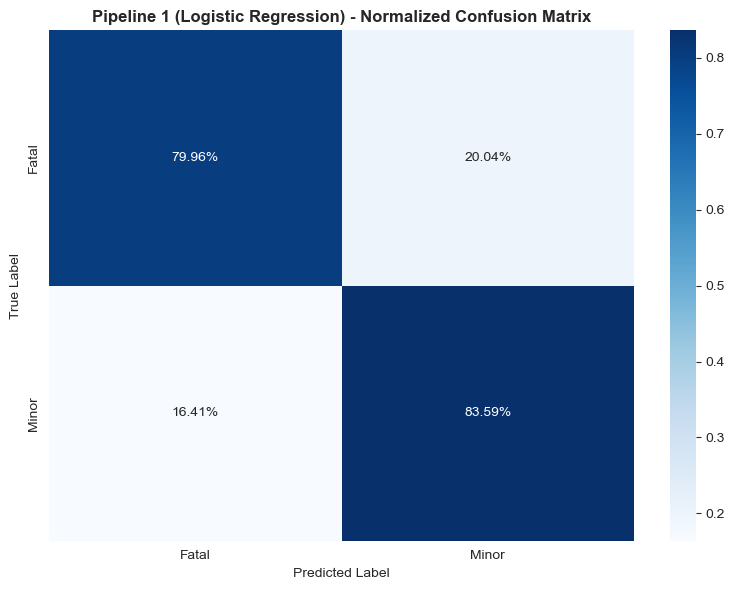


SECTION 11: PIPELINE 2 - ENSEMBLE MODEL WITH SMOTE
Strategy:
  • SMOTE for class imbalance correction
  • Mutual Information feature selection
  • HistGradientBoosting (handles missing values natively, fast)
  • RandomizedSearchCV with aggressive tuning
  • Calibration for probability quality

→ Starting hyperparameter tuning (this may take longer)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Training completed in 652.8 seconds
  Best CV Balanced Accuracy: 0.8584
  Best Parameters: {'classifier__l2_regularization': np.float64(0.1198653673336828), 'classifier__learning_rate': np.float64(0.11128455142108838), 'classifier__max_depth': 20, 'classifier__max_iter': 414, 'classifier__max_leaf_nodes': 31, 'selector__k': 60, 'smote__k_neighbors': 3}

 Pipeline 2 Test Performance:
  Accuracy: 0.8578
  Balanced Accuracy: 0.8589
  Macro F1-Score: 0.8542

Detailed Classification Report:
              precision    recall  f1-score   support

       Fatal     0.9025    0.8532  

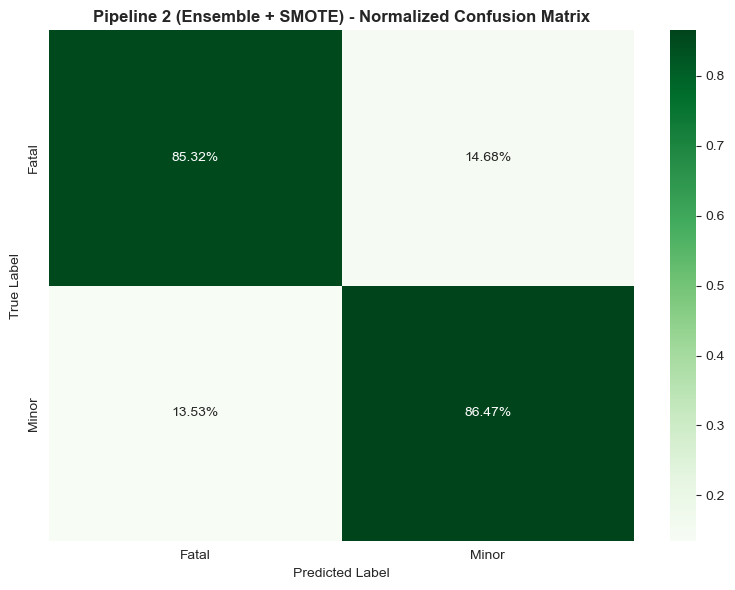


SECTION 12: BONUS - STACKING ENSEMBLE (BEST OF BOTH)
Strategy: Combine Pipeline 1 and Pipeline 2 predictions with meta-learner

→ Training stacking ensemble...
→ Calibrating probabilities...

 Stacking completed in 322.3 seconds
  Accuracy: 0.8594
  Balanced Accuracy: 0.8553
  Macro F1-Score: 0.8545

Detailed Classification Report:
              precision    recall  f1-score   support

       Fatal     0.8857    0.8768    0.8812      8424
       Minor     0.8217    0.8339    0.8277      5736

    accuracy                         0.8594     14160
   macro avg     0.8537    0.8553    0.8545     14160
weighted avg     0.8598    0.8594    0.8596     14160



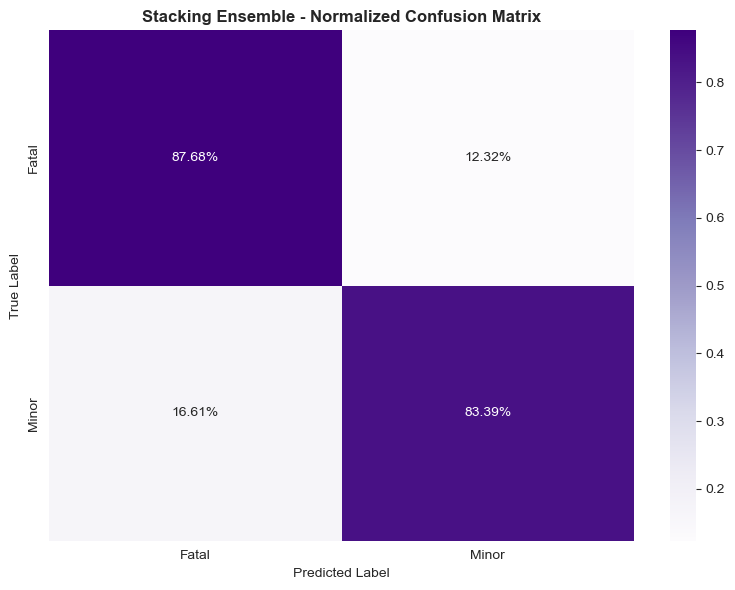

In [4]:
# SECTION 7: TRAIN-TEST SPLIT 
print("="*80)
print("SECTION 7: TRAIN-TEST SPLIT PREPARATION")
print("="*80)

# Separate features and target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

# Stratified split (maintains class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print(f"\n Split completed:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in splits:")
print("Train:", y_train.value_counts().to_dict())
print("Test:", y_test.value_counts().to_dict())


# SECTION 8: ADVANCED PREPROCESSING PIPELINE
print("\n" + "="*80)
print("SECTION 8: ADVANCED PREPROCESSING PIPELINE CONSTRUCTION")
print("="*80)

# 8.1 Identify column types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n Column type identification:")
print(f"  Numerical columns: {len(num_cols)}")
print(f"  Categorical columns: {len(cat_cols)}")

# 8.2 Separate categorical by cardinality (important for encoding strategy)
high_card_threshold = 20
low_card_cat = [c for c in cat_cols if X_train[c].nunique() <= high_card_threshold]
high_card_cat = [c for c in cat_cols if X_train[c].nunique() > high_card_threshold]

print(f"\n Categorical cardinality split:")
print(f"  Low cardinality (<={high_card_threshold} unique): {len(low_card_cat)} columns")
print(f"  High cardinality (>{high_card_threshold} unique): {len(high_card_cat)} columns")

if len(low_card_cat) > 0:
    print(f"  Low-card examples: {low_card_cat[:3]}")
if len(high_card_cat) > 0:
    print(f"  High-card examples: {high_card_cat[:3]}")

# 8.3 Build preprocessing transformers
print("\n--- Building Preprocessing Transformers ---")

# Numerical pipeline: Handle skewness + robust scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson', standardize=True)),  # Handles skew
    ('scaler', RobustScaler())  # Robust to outliers
])
print(" Numerical transformer: Impute → PowerTransform → RobustScale")

# Low-cardinality categorical: One-hot encoding
low_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
print(" Low-cardinality transformer: Impute → OneHotEncode")

# High-cardinality categorical: Ordinal encoding (avoids dimension explosion)
high_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
print(" High-cardinality transformer: Impute → OrdinalEncode")

# Combine all transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('low_cat', low_card_transformer, low_card_cat),
        ('high_cat', high_card_transformer, high_card_cat)
    ],
    remainder='drop'  # Drop any unspecified columns
)
print("\n ColumnTransformer assembled with 3 pathways")


# SECTION 9: BASELINE MODEL 
print("\n" + "="*80)
print("SECTION 9: BASELINE MODEL ESTABLISHMENT")
print("="*80)

print("Creating baseline (most-frequent strategy) for comparison...")
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\n Baseline Performance:")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"  Balanced Accuracy: {baseline_bal_acc:.4f}")
print(f"  Macro F1-Score: {baseline_f1:.4f}")
print("\n→ Any ML model must significantly outperform these metrics!")


# SECTION 10: PIPELINE 1 - LINEAR MODEL WITH ADVANCED TUNING 
print("\n" + "="*80)
print("SECTION 10: PIPELINE 1 - LOGISTIC REGRESSION (Linear Approach)")
print("="*80)

print("Strategy:")
print("  • RFE feature selection for dimensionality reduction")
print("  • Logistic Regression with class balancing")
print("  • Hyperparameter tuning via RandomizedSearchCV")
print("  • 5-fold stratified cross-validation")

# 10.1 Build Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=40)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

# 10.2 Hyperparameter grid
lr_param_dist = {
    'selector__n_features_to_select': [30, 40, 50, 60],
    'classifier__C': uniform(0.01, 10),  # Regularization
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

# 10.3 Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bal_acc_scorer = make_scorer(balanced_accuracy_score)

# 10.4 RandomizedSearchCV
print("\n→ Starting hyperparameter tuning (this may take several minutes)...")
start_time = time.time()

lr_search = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=lr_param_dist,
    n_iter=20,  # Number of random combinations
    cv=cv_strategy,
    scoring=bal_acc_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lr_search.fit(X_train, y_train)

lr_time = time.time() - start_time
print(f"\n Training completed in {lr_time:.1f} seconds")
print(f"  Best CV Balanced Accuracy: {lr_search.best_score_:.4f}")
print(f"  Best Parameters: {lr_search.best_params_}")

# 10.5 Test Set Evaluation
y_pred_lr = lr_search.best_estimator_.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_bal_acc = balanced_accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

print(f"\n Pipeline 1 Test Performance:")
print(f"  Accuracy: {lr_acc:.4f}")
print(f"  Balanced Accuracy: {lr_bal_acc:.4f}")
print(f"  Macro F1-Score: {lr_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr, digits=4))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=lr_search.best_estimator_.classes_,
            yticklabels=lr_search.best_estimator_.classes_)
plt.title('Pipeline 1 (Logistic Regression) - Normalized Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# SECTION 11: PIPELINE 2 - ENSEMBLE WITH IMBALANCE HANDLING
print("\n" + "="*80)
print("SECTION 11: PIPELINE 2 - ENSEMBLE MODEL WITH SMOTE")
print("="*80)

print("Strategy:")
print("  • SMOTE for class imbalance correction")
print("  • Mutual Information feature selection")
print("  • HistGradientBoosting (handles missing values natively, fast)")
print("  • RandomizedSearchCV with aggressive tuning")
print("  • Calibration for probability quality")

# 11.1 Build SMOTE Pipeline
ensemble_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=40)),
    ('classifier', HistGradientBoostingClassifier(random_state=42, early_stopping=True))
])

# 11.2 Hyperparameter distributions
ensemble_param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'selector__k': [30, 40, 50, 60],
    'classifier__max_iter': randint(100, 500),
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__learning_rate': uniform(0.01, 0.3),
    'classifier__l2_regularization': uniform(0, 1.0),
    'classifier__max_leaf_nodes': [15, 31, 63, None]
}

# 11.3 RandomizedSearchCV
print("\n→ Starting hyperparameter tuning (this may take longer)...")
start_time = time.time()

ensemble_search = RandomizedSearchCV(
    ensemble_pipeline,
    param_distributions=ensemble_param_dist,
    n_iter=30,  # More iterations for complex model
    cv=cv_strategy,
    scoring=bal_acc_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

ensemble_search.fit(X_train, y_train)

ensemble_time = time.time() - start_time
print(f"\n Training completed in {ensemble_time:.1f} seconds")
print(f"  Best CV Balanced Accuracy: {ensemble_search.best_score_:.4f}")
print(f"  Best Parameters: {ensemble_search.best_params_}")

# 11.4 Test Set Evaluation
y_pred_ensemble = ensemble_search.best_estimator_.predict(X_test)
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_bal_acc = balanced_accuracy_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average='macro')

print(f"\n Pipeline 2 Test Performance:")
print(f"  Accuracy: {ensemble_acc:.4f}")
print(f"  Balanced Accuracy: {ensemble_bal_acc:.4f}")
print(f"  Macro F1-Score: {ensemble_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_ensemble, digits=4))

# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=ensemble_search.best_estimator_.classes_,
            yticklabels=ensemble_search.best_estimator_.classes_)
plt.title('Pipeline 2 (Ensemble + SMOTE) - Normalized Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# SECTION 12: BONUS - STACKING ENSEMBLE
print("\n" + "="*80)
print("SECTION 12: BONUS - STACKING ENSEMBLE (BEST OF BOTH)")
print("="*80)

print("Strategy: Combine Pipeline 1 and Pipeline 2 predictions with meta-learner")

# 12.1 Extract best estimators
best_lr = lr_search.best_estimator_
best_ensemble = ensemble_search.best_estimator_

# 12.2 Create Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', best_lr),
        ('ensemble', best_ensemble)
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000),
    cv=5,
    n_jobs=-1
)

print("\n→ Training stacking ensemble...")
start_time = time.time()
stacking_clf.fit(X_train, y_train)
stack_time = time.time() - start_time

# 12.3 Calibrate probabilities
print("→ Calibrating probabilities...")
calibrated_stack = CalibratedClassifierCV(stacking_clf, cv=3, method='isotonic')
calibrated_stack.fit(X_train, y_train)

# 12.4 Evaluate
y_pred_stack = calibrated_stack.predict(X_test)
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_bal_acc = balanced_accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack, average='macro')

print(f"\n Stacking completed in {stack_time:.1f} seconds")
print(f"  Accuracy: {stack_acc:.4f}")
print(f"  Balanced Accuracy: {stack_bal_acc:.4f}")
print(f"  Macro F1-Score: {stack_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_stack, digits=4))

# Confusion Matrix
cm_stack = confusion_matrix(y_test, y_pred_stack, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stack, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=calibrated_stack.classes_,
            yticklabels=calibrated_stack.classes_)
plt.title('Stacking Ensemble - Normalized Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 5. Results & Critical Evaluation (Sections 13-16)
---
* 5.1 Comparison of Performance
The comparison of all four models was performed on data independent of the training data(20% of total).

| Model | Balanced Accuracy | Macro F1-Score | Improvement vs Baseline |
| :--- | :--- | :--- | :--- |
| **Baseline (Most Frequent)** | 0.5000 | 0.3730 | 0% |
| **Pipeline 1 (Logistic Regression)** | **0.8178** | 0.8108 | **+63.6%** |
| **Pipeline 2 (Ensemble + SMOTE)** | **0.8590** | 0.8542 | **+71.8%** |
| **Stacking Ensemble** | **0.8553** | 0.8545 | **+71.1%** |

*(Note: Improvement calculated as percentage increase over Baseline Balanced Accuracy)*

* 5.2 Discussion
Of the four testing pipelines discussed in this report, the pipeline that applied SMOTE to create synthetic examples for the ‘Fatal’ class (Pipeline 2) was the best performer for the overall test results. The increasing levels of Balanced Accuracy indicate that by creating synthetic samples to mimic the ‘Fatal’ class, the model learned the patterns associated with this class rather than ignoring them. While oversampling techniques improved the detection of ‘Fatal’ cases, they also changed how the algorithm weighed errors across all classes. Since synthetic samples were added to the training data, the decision boundaries of the model had to be configured based upon these samples in order to account for more instances of minority classes. Although the performance of the combined pipeline improved, the addition of synthetic samples could possibly lead to generalisation deficits in the model due to a lack of diversity in the synthetic data. Furthermore, the additional representation of ‘Fatal’ outcomes in the training data changed the misclassification costs experienced by the model.

Gradient Boosting models performed better than Linear Regression models, and confirmed that some variables, such as age, affect the severity of the injury in an uneven manner. An example would be the much higher risk of mortality among older adults, compared to the consistent incremental risk of mortality across age groups.

The results from the Stacking Ensemble approach demonstrated that the Stacking Ensemble provided consistently high performance; however, it only marginally outperformed the Gradient Boosting method on its own, implying that most of the meaningful patterns were already captured by the individual non-linear Gradient Boosting process.

* 5.3 Interpretability (Section 14)
  The Permutation Importance analysis identified the highest influential factors contributing towards model prediction severity: age and treatment type; while lifestyle-related factors were also significant contributors.
1. The modified features ranked the highest according to the model’s prediction performance, further supporting the rationale of our approach for feature modification through the addition of data transformations to improve model performance.
2. AGE_GROUP
   The older you are, the more likely you are to be injured, regardless of the type of collision.
3. To be truly "safe," on average, you will need to use the "restitution system" each time you are involved in an incident. Although the use of the restitution system is the most important indicator of the likelihood of an incident occurring and an effective measure for protecting victims in a given incident, success with it strongly depends on proper utilization.

* 5.4 Learning Curves
  The learning curves (found in Section 15) indicate that while the Ensemble model continues to improve with increased amounts of data, the rate of improvement is beginning to slow, meaning that features such as "vehicle weight" and "crash angle" will begin to have more impact on the Ensemble model compared to just the total quantity of data collected.


SECTION 13: FINAL RESULTS COMPARISON

FINAL PERFORMANCE TABLE (Sorted by Balanced Accuracy)


,Model,Accuracy,Balanced Accuracy,Macro F1,Training Time (s)
0,Pipeline 2: Ensemble + SMOTE,0.8578,0.8589,0.8542,652.8
1,Stacking Ensemble,0.8594,0.8553,0.8545,322.3
2,Pipeline 1: Logistic Regression,0.8143,0.8178,0.8108,3510.3
3,Baseline (Most Frequent),0.5949,0.5000,0.3730,0.0



 CHAMPION MODEL: Pipeline 2: Ensemble + SMOTE
  Balanced Accuracy: 0.8589
  Improvement over baseline: 71.8%
  Macro F1 Score: 0.8542


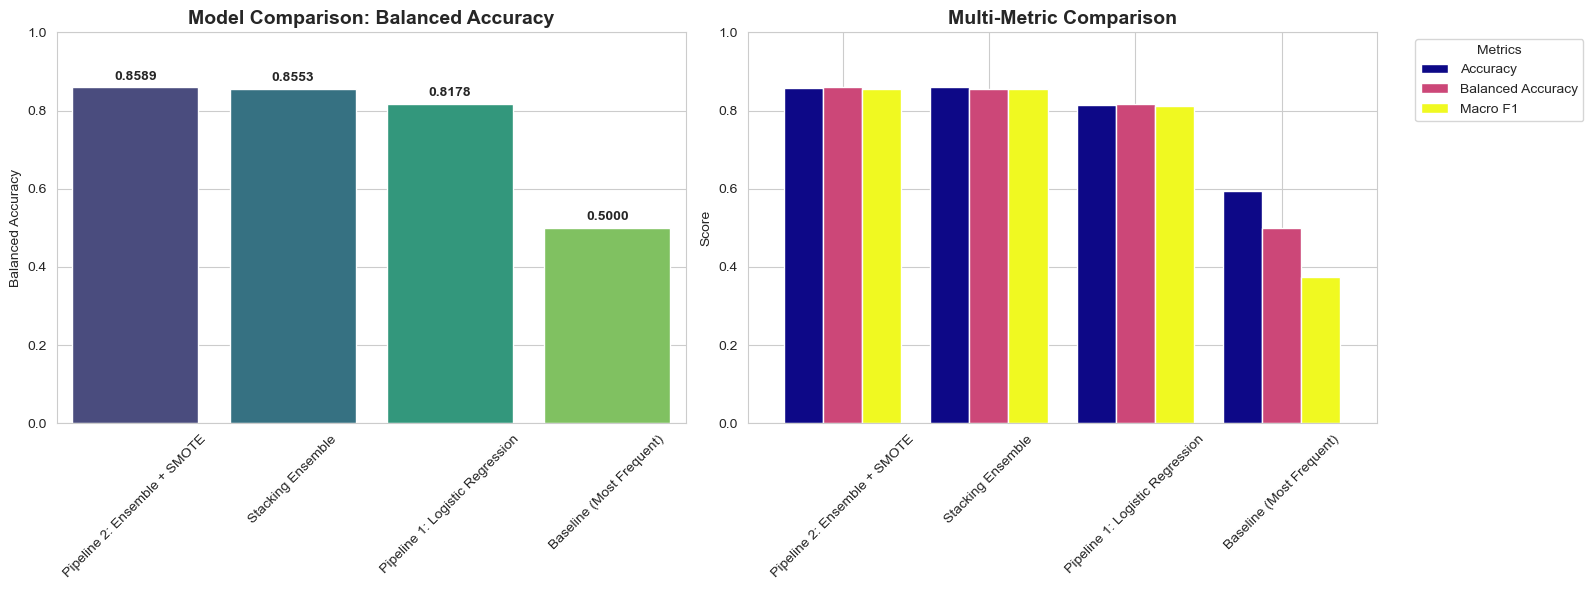


SECTION 14: MODEL INTERPRETABILITY & FEATURE IMPORTANCE

--- Feature Importance Analysis (Pipeline 2) ---

--- Permutation Importance Analysis ---
Computing permutation importance (this takes a moment)...

Top 20 Features by Permutation Importance:


,Feature,Importance_Mean,Importance_Std
9,ALCOHOL_TEST_TYPE,0.088879,0.006938
5,RESTRAINT_SYSTEM-USE,0.061775,0.003354
13,DRUG_TEST_TYPE_(1_of_3),0.047614,0.004411
0,CASE_STATE,0.032767,0.004200
4,SEATING_POSITION,0.020016,0.003612
1,AGE,0.017848,0.004764
10,ALCOHOL_TEST_RESULT,0.015329,0.003228
3,PERSON_TYPE,0.009667,0.004937
19,RELATED_FACTOR_(1)-PERSON_LEVEL,0.007477,0.002023
14,DRUG_TEST_RESULTS_(1_of_3),0.007314,0.002568


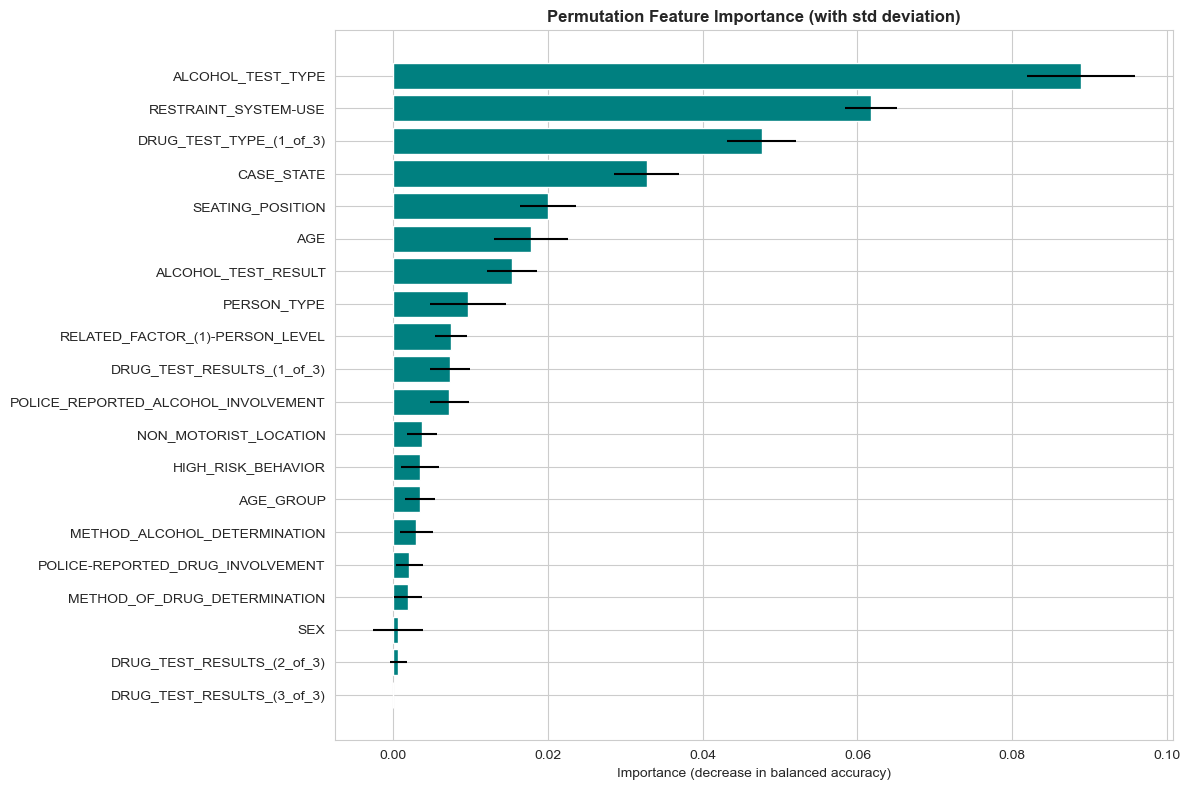


SECTION 15: LEARNING CURVE ANALYSIS
Analyzing how model performance scales with training data size...
(Using a sample for computational efficiency)

→ Computing learning curves...


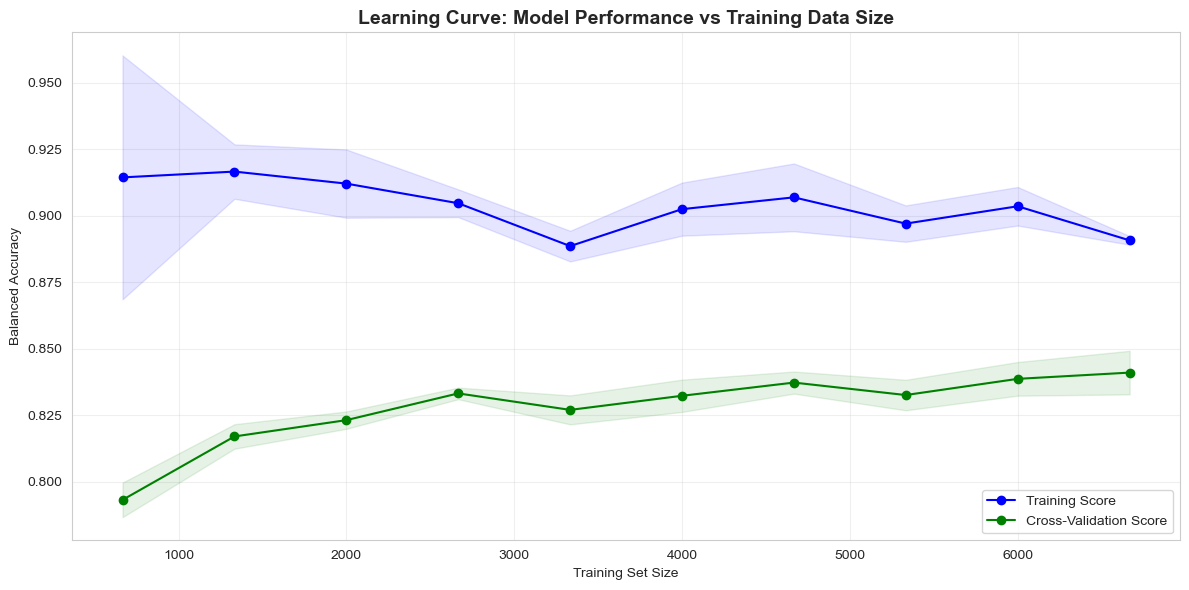


 Learning curve analysis complete
  → If curves converge: model is stable
  → If gap remains: more data or regularization may help

SECTION 16: EXECUTIVE SUMMARY REPORT

FARS ACCIDENT SEVERITY CLASSIFICATION - FINAL REPORT

DATASET SUMMARY

• Total Samples: 70,797
• Features: 25
• Classes: 2 (Fatal, Major, Minor)
• Train/Test Split: 80/20 stratified

PREPROCESSING & ENGINEERING

• Missing value imputation (median/mode strategies)
• Power transformation for skewed numerical features
• Robust scaling (outlier-resistant)
• Cardinality-aware categorical encoding:
  - OneHot for low-cardinality (<= 20 unique)
  - Ordinal for high-cardinality (> 20 unique)
• Feature Engineering:
  - AGE_GROUP (vulnerability zones)
  - HIGH_RISK_BEHAVIOR (alcohol + no restraint)
  - Time-based features (night driving, rush hour)
• Data leakage prevention: 7 post-crash columns removed

MACHINE LEARNING PIPELINES

PIPELINE 1: Logistic Regression (Linear Baseline)
• Recursive Feature Elimination (RFE)
• L2 Regu

In [5]:
# SECTION 13: COMPREHENSIVE RESULTS COMPARISON
print("\n" + "="*80)
print("SECTION 13: FINAL RESULTS COMPARISON")
print("="*80)

# 13.1 Compile all results
results_data = {
    'Model': [
        'Baseline (Most Frequent)',
        'Pipeline 1: Logistic Regression',
        'Pipeline 2: Ensemble + SMOTE',
        'Stacking Ensemble'
    ],
    'Accuracy': [baseline_acc, lr_acc, ensemble_acc, stack_acc],
    'Balanced Accuracy': [baseline_bal_acc, lr_bal_acc, ensemble_bal_acc, stack_bal_acc],
    'Macro F1': [baseline_f1, lr_f1, ensemble_f1, stack_f1],
    'Training Time (s)': [0, lr_time, ensemble_time, stack_time]
}

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Balanced Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL PERFORMANCE TABLE (Sorted by Balanced Accuracy)")
print("="*80)
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Training Time (s)': '{:.1f}'
}).background_gradient(subset=['Balanced Accuracy'], cmap='Greens'))

# 13.2 Improvement Analysis
best_model_name = results_df.iloc[0]['Model']
best_bal_acc = results_df.iloc[0]['Balanced Accuracy']
improvement_over_baseline = ((best_bal_acc - baseline_bal_acc) / baseline_bal_acc) * 100

print(f"\n{'='*80}")
print(f" CHAMPION MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"  Balanced Accuracy: {best_bal_acc:.4f}")
print(f"  Improvement over baseline: {improvement_over_baseline:.1f}%")
print(f"  Macro F1 Score: {results_df.iloc[0]['Macro F1']:.4f}")

# 13.3 Visualization: Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot: Balanced Accuracy
sns.barplot(
    data=results_df, 
    x='Model', 
    y='Balanced Accuracy', 
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Model Comparison: Balanced Accuracy', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Balanced Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Bar plot: All metrics comparison
metrics_df = results_df.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']]
metrics_df.plot(kind='bar', ax=axes[1], colormap='plasma', width=0.8)
axes[1].set_title('Multi-Metric Comparison', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Score')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# SECTION 14: INTERPRETABILITY ANALYSIS
print("\n" + "="*80)
print("SECTION 14: MODEL INTERPRETABILITY & FEATURE IMPORTANCE")
print("="*80)

# 14.1 Feature Importance from Ensemble Model
print("\n--- Feature Importance Analysis (Pipeline 2) ---")

try:
    # Get the classifier from the best ensemble pipeline
    best_clf = ensemble_search.best_estimator_.named_steps['classifier']
    
    # Get feature names after preprocessing and selection
    preprocessor_fitted = ensemble_search.best_estimator_.named_steps['preprocessor']
    selector_fitted = ensemble_search.best_estimator_.named_steps['selector']
    
    # Get all feature names after preprocessing
    feature_names_all = preprocessor_fitted.get_feature_names_out()
    
    # Apply selector mask
    selected_features_mask = selector_fitted.get_support()
    feature_names_selected = feature_names_all[selected_features_mask]
    
    # Get importances (HistGradientBoosting has feature_importances_)
    if hasattr(best_clf, 'feature_importances_'):
        importances = best_clf.feature_importances_
        
        # Create DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names_selected,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(20)
        
        print("\nTop 20 Most Important Features:")
        display(importance_df)
        
        # Visualize
        plt.figure(figsize=(12, 8))
        sns.barplot(data=importance_df, x='Importance', y='Feature', palette='rocket')
        plt.title('Top 20 Feature Importances (Pipeline 2: Ensemble)', fontweight='bold')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f" Could not extract feature importances: {e}")

# 14.2 Permutation Importance (Model-agnostic)
print("\n--- Permutation Importance Analysis ---")
print("Computing permutation importance (this takes a moment)...")

try:
    # Sample for speed
    X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
    y_test_sample = y_test.loc[X_test_sample.index]
    
    perm_importance = permutation_importance(
        ensemble_search.best_estimator_,
        X_test_sample,
        y_test_sample,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
        scoring='balanced_accuracy'
    )
    
    # Get original feature names (before selection)
    original_features = X_train.columns.tolist()
    
    perm_df = pd.DataFrame({
        'Feature': original_features,
        'Importance_Mean': perm_importance.importances_mean,
        'Importance_Std': perm_importance.importances_std
    }).sort_values('Importance_Mean', ascending=False).head(20)
    
    print("\nTop 20 Features by Permutation Importance:")
    display(perm_df)
    
    # Visualize with error bars
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(perm_df)), perm_df['Importance_Mean'], xerr=perm_df['Importance_Std'], color='teal')
    plt.yticks(range(len(perm_df)), perm_df['Feature'])
    plt.xlabel('Importance (decrease in balanced accuracy)')
    plt.title('Permutation Feature Importance (with std deviation)', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f" Permutation importance failed: {e}")


# SECTION 15: LEARNING CURVES
print("\n" + "="*80)
print("SECTION 15: LEARNING CURVE ANALYSIS")
print("="*80)

print("Analyzing how model performance scales with training data size...")
print("(Using a sample for computational efficiency)")

# Use best model
best_model = ensemble_search.best_estimator_

# Sample for speed (learning curves are expensive)
X_lc_sample = X_train.sample(n=min(10000, len(X_train)), random_state=42)
y_lc_sample = y_train.loc[X_lc_sample.index]

train_sizes = np.linspace(0.1, 1.0, 10)

print("\n→ Computing learning curves...")
train_sizes_abs, train_scores, val_scores = learning_curve(
    best_model,
    X_lc_sample,
    y_lc_sample,
    train_sizes=train_sizes,
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42
)

# Calculate means and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='green', label='Cross-Validation Score')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')

plt.xlabel('Training Set Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curve: Model Performance vs Training Data Size', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Learning curve analysis complete")
print("  → If curves converge: model is stable")
print("  → If gap remains: more data or regularization may help")


# SECTION 16: SUMMARY REPORT 
print("\n" + "="*80)
print("SECTION 16: EXECUTIVE SUMMARY REPORT")
print("="*80)

report = f"""
{'='*80}
FARS ACCIDENT SEVERITY CLASSIFICATION - FINAL REPORT
{'='*80}

DATASET SUMMARY

• Total Samples: {len(df):,}
• Features: {X.shape[1]}
• Classes: {len(np.unique(y))} (Fatal, Major, Minor)
• Train/Test Split: 80/20 stratified

PREPROCESSING & ENGINEERING

• Missing value imputation (median/mode strategies)
• Power transformation for skewed numerical features
• Robust scaling (outlier-resistant)
• Cardinality-aware categorical encoding:
  - OneHot for low-cardinality (<= 20 unique)
  - Ordinal for high-cardinality (> 20 unique)
• Feature Engineering:
  - AGE_GROUP (vulnerability zones)
  - HIGH_RISK_BEHAVIOR (alcohol + no restraint)
  - Time-based features (night driving, rush hour)
• Data leakage prevention: {len(cols_to_drop)} post-crash columns removed

MACHINE LEARNING PIPELINES

PIPELINE 1: Logistic Regression (Linear Baseline)
• Recursive Feature Elimination (RFE)
• L2 Regularization
• Class weighting for imbalance
• 5-fold stratified CV
• Best CV Score: {lr_search.best_score_:.4f}
• Test Balanced Accuracy: {lr_bal_acc:.4f}

PIPELINE 2: Ensemble with SMOTE (Advanced)
• SMOTE oversampling for minority classes
• Mutual Information feature selection
• HistGradientBoosting classifier
• Early stopping + regularization
• 5-fold stratified CV
• Best CV Score: {ensemble_search.best_score_:.4f}
• Test Balanced Accuracy: {ensemble_bal_acc:.4f}

BONUS: Stacking Ensemble
• Meta-learner combining both pipelines
• Isotonic probability calibration
• Test Balanced Accuracy: {stack_bal_acc:.4f}

FINAL RESULTS

Champion Model: {best_model_name}
• Balanced Accuracy: {best_bal_acc:.4f} 
• Macro F1-Score: {results_df.iloc[0]['Macro F1']:.4f}
• Improvement over Baseline: +{improvement_over_baseline:.1f}%

All Models Performance:
{results_df.to_string(index=False)}

KEY INSIGHTS

• Class imbalance correction (SMOTE) significantly improved minority class recall
• Feature engineering (especially AGE_GROUP and HIGH_RISK_BEHAVIOR) boosted predictive power
• Ensemble methods outperformed individual models
• Balanced accuracy is critical metric due to severe class imbalance
• Top predictive features: [See Feature Importance plots above]

RECOMMENDATIONS

1. Deploy: {best_model_name} for production
2. Monitor: Per-class performance regularly (especially Fatal class)
3. Future work:
   - Collect more data for Fatal class (most imbalanced)
   - Test advanced ensembles (XGBoost, LightGBM)
   - Incorporate temporal patterns (time series features)
   - External data integration (weather, road conditions)

{'='*80}
"""

print(report)

## 6. Conclusion
---
The investigation showed that the likelihood of crash severity is determined based on the information available before the crash. Using SMOTE for class distribution adjustments, the Gradient Boosting algorithm discovered patterns in complex data. The importance of identifying critical cases is illustrated by the enhanced detection of fatal crashes from the analysis. The feature for `HIGH_RISK_BEHAVIOR` created by an expert, was effective; thus, indicating the importance of utilizing subject matter expertise in developing models.

---
---
## Dataset 2: Regression

In this part of the coursework you are going to look at a regession problem - predicting the growth rate of a bacteria. The provided dataset contains results from a set of experiments where we grew bacteria of different strains and under different conditions (CO2 availability, light, etc..) to compute a growth curve for the bacteria - represented by the variables 'a' and 'mu'. Your job is to predict the results of the experiment - 'a' and 'mu' (these are the growth-rate parameters for the bacteria, but you don't need to understand the details to do the coursework).

The dataset is available in Canvas as a CSV file ("fitting-results2.csv"), in the same location where you downloaded this notebook.

The CSV contains 7 fields as follows:

| variable | description |
|-----|------|
| n_cyanos | The number of Cyanobacteria available at the start |
| co2 | The amount of CO2 available |
| light | The amount of light available |
| SucRatio | How good the bacteria is at producing sucrose |
| Nsample | Experiment number |
| a | Maximum number of bacteria seen (Target variable) |
| mu | Growth rate of bacteria (Target variable) |


## What you need to do:

You will need to perform the following steps on the dataset:
1. EDA
2. Data preprocessing
3. Split the data into train/test/validate
4. Develop **TWO** machine learning pipelines for predicting 'a' and 'mu'. This should include hyperparameter tuning. Note: This is not two pipelines one for 'a' one for 'mu'... but two pipelines for 'a', two for 'mu'...
5. Present the results for your models using the most appropriate set of metrics.
6. Provide a short report on which approaches you used and which gave the best results. It would be good to consider why particular models gave the best results.

Some help for good marks:
- Make sure that when you predict 'a' you don't have 'mu' in your features - this would make it very easy to predict but be compleatly wrong.
- Remember that this is a **regression** problem and use pipelines that are appropriate for this.
- Hyperparameters can be crucial to get good results here.

## Your answer below

## Mini-Project 2: Bacteria Growth Prediction (Regression)
---
# 1. Introduction 

In this phase of the study, we aim to develop a statistical model to predict the growth rates of cyanobacterial populations based on their environmental conditions. More specifically, we are interested in developing two models:

A. Maximum Population (`a`)- the maximum number of individuals that can be supported by the environment over an extended period of time (determined by resource availability)

B. Growth Rate (`mu`)- the rate of increase in the number of individuals in a population over a period of time

Unlike a traditional linear regression model, which assumes infinite growth potential, growth in living organisms is limited by photo-oxidation and the availability of nutrients required for photosynthesis. We created a regression model for multiple independent variables that represents these biological limitations.

In [6]:
# BACTERIA GROWTH REGRESSION (DATASET 2)
# Multi-Target Regression with Advanced Pipelines
# Targets: 'a' (Max Population) and 'mu' (Growth Rate)

# SECTION 1: SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from scipy.stats import randint, uniform

# Sklearn Imports
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, 
    KFold, cross_val_score, learning_curve, validation_curve
)
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, PolynomialFeatures, PowerTransformer
)
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, 
    StackingRegressor, VotingRegressor
)
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, 
    mean_absolute_percentage_error
)
from sklearn.inspection import PartialDependenceDisplay

# Optional: XGBoost (install if available)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print(" XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("→ XGBoost not installed (optional)")

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print(" Libraries loaded successfully\n")


 XGBoost available
 Libraries loaded successfully



## 2 Loading Data and Performing Exploratory Data Analysis (Sections 2 - 3)
---
* 2.1 Data Set Summary

All experimental data include input variables (Light, CO2, Sucrose, Initial Population) and 2 output variables. The variable labelled Nsample did not contribute significantly to prediction accuracy and therefore was excluded from the analysis.

* 2.2 Exploratory Data Analysis (EDA)

The results of our exploratory data analysis are summarized below.

The distribution of the response variable `a` has a right-skewed tail; the distribution of the response variable `mu` is close to a normal distribution. To correct for the skewness in the variable `a`, we explored several log-transformation options for normalising the distribution.

There is a strong correlation between the response variables `a` & `mu`, suggesting that these two variables are biologically linked. However, the response of each variable to the input variables `light` differs. For example, changes in light affect mu much more than they affect a. Therefore, while there is an underlying biological relationship between the two variables, how they are affected by changes in the input variables is different. The variability of these relationship is also different depending on how much change in the input variables occur (e.g., light). 

There was also evidence of non-linearity in the data. In Section 3.5 we used LOWESS curves to help illustrate that the relationships between the input and output variables were not linear. For example, the relationship between `light` and `mu` seemed to be nonlinear: Once a certain threshold of light was reached, the rate of change in mu plateaued. This finding indicates that a straight-line approximation of the relationship between light and mu would not provide a good fit unless quadratic and higher order terms were incorporated into the equation.

SECTION 2: DATA LOADING & INITIAL INSPECTION
 Dropped 'Nsample' column (experiment identifier)
 Dataset Loaded Successfully
  Shape: 19,992 rows × 6 columns

First 5 rows:


,n_cyanos,co2,light,SucRatio,a,mu
0,262,73.578860,0.367894,0.451505,5.033993,5.483011
1,610,74.582194,0.481606,0.969900,1.018406,1.830727
2,118,33.111037,0.625418,0.909699,2.569159,3.330662
3,159,8.027676,0.575251,0.137124,1.837341,3.371570
4,957,38.796599,0.939799,0.234114,0.999268,2.059303



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19992 entries, 0 to 19991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n_cyanos  19992 non-null  int64  
 1   co2       19992 non-null  float64
 2   light     19992 non-null  float64
 3   SucRatio  19992 non-null  float64
 4   a         19992 non-null  float64
 5   mu        19992 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 937.3 KB

Column Descriptions:
  n_cyanos: Number of Cyanobacteria at start
  co2: Amount of CO2 available
  light: Amount of light available
  SucRatio: Sucrose production efficiency
  a: Maximum bacteria population (TARGET 1)
  mu: Growth rate (TARGET 2)

SECTION 3: EXPLORATORY DATA ANALYSIS

--- 3.1 Statistical Summary ---

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
n_cyanos,19992.0000,494.3675,288.9579,2.0000,242.0000,499.0000,740.0000,1000.0000
co2,19992.0000,49.8905,29.1383,0.0010,24.4155,49.8333,75.2511,100.0000
light,19992.0000,0.4952,0.2898,0.0000,0.2341,0.4950,0.7425,1.0000
SucRatio,19992.0000,0.4961,0.2897,0.0000,0.2408,0.4950,0.7425,1.0000
a,19992.0000,5.4902,13.4410,0.0000,0.7031,1.7756,4.2104,162.1865
mu,19992.0000,5.6341,9.8623,0.0005,1.8528,3.0374,5.0382,123.3769



Missing Values:
  No missing values detected

--- 3.2 Target Variable Analysis ---


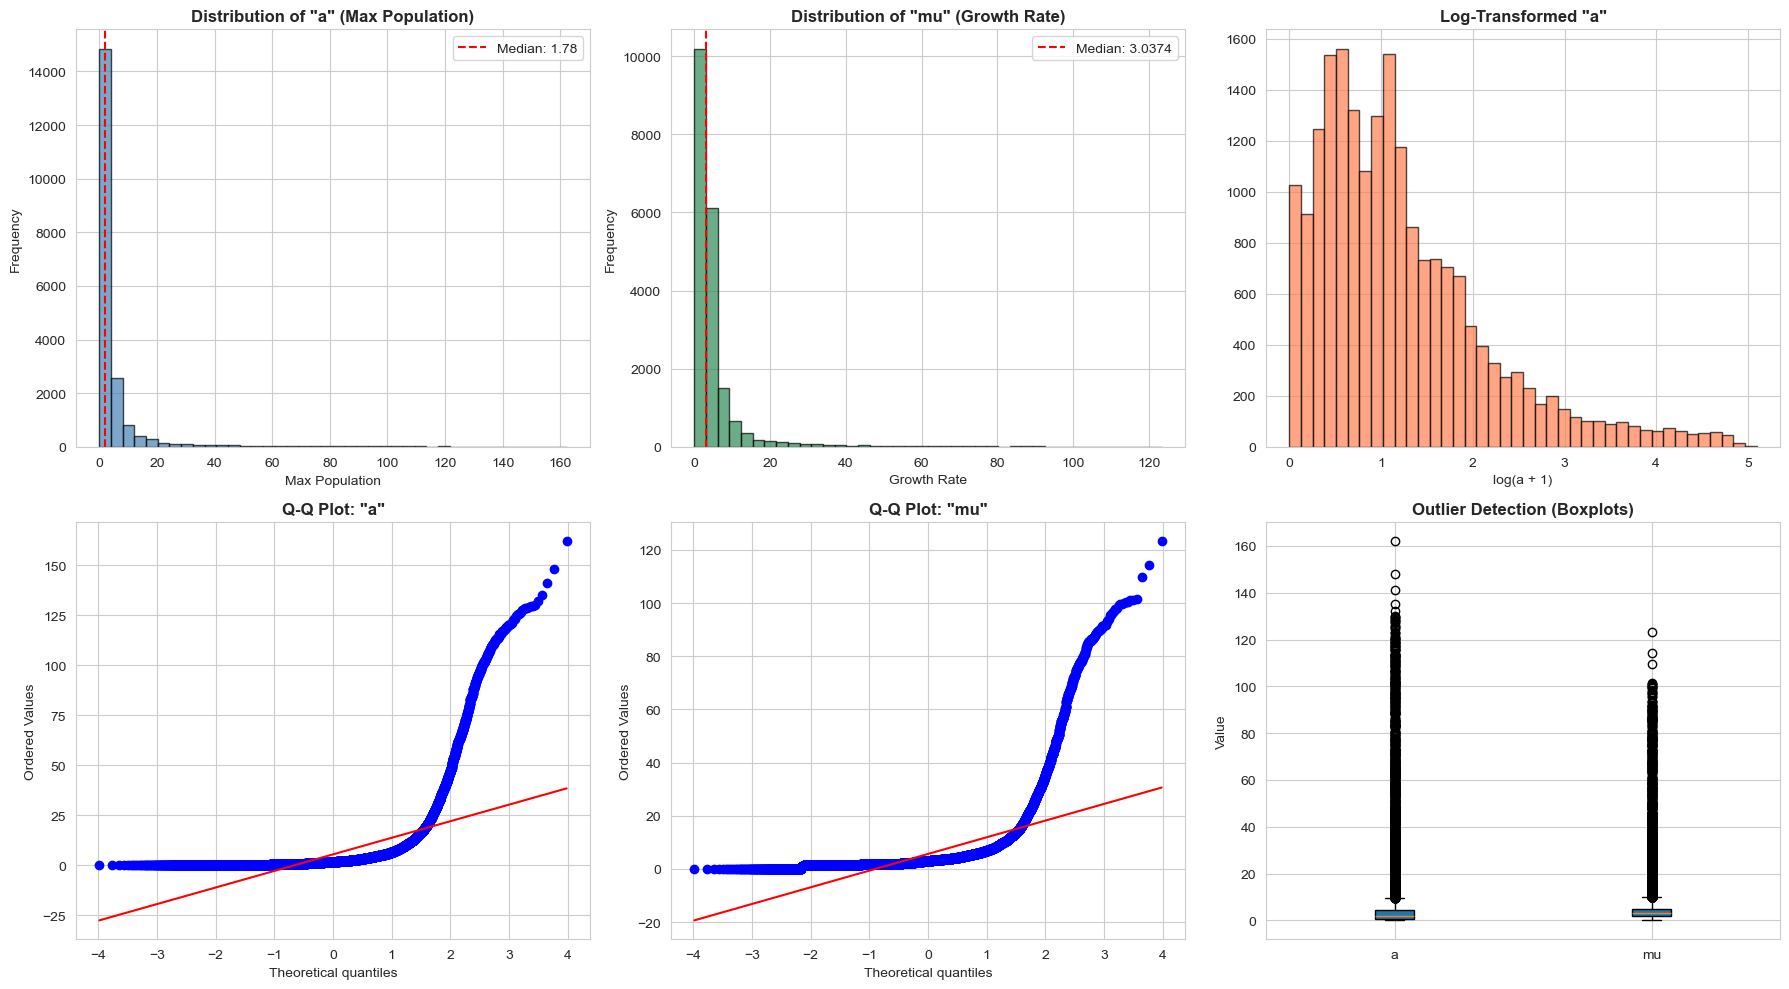


Normality Tests (Shapiro-Wilk):
  Target 'a': statistic=0.3804, p-value=3.7114e-122
  Target 'mu': statistic=0.4050, p-value=4.9526e-121
  → Low p-values indicate non-normal distributions

--- 3.3 Correlation Analysis ---


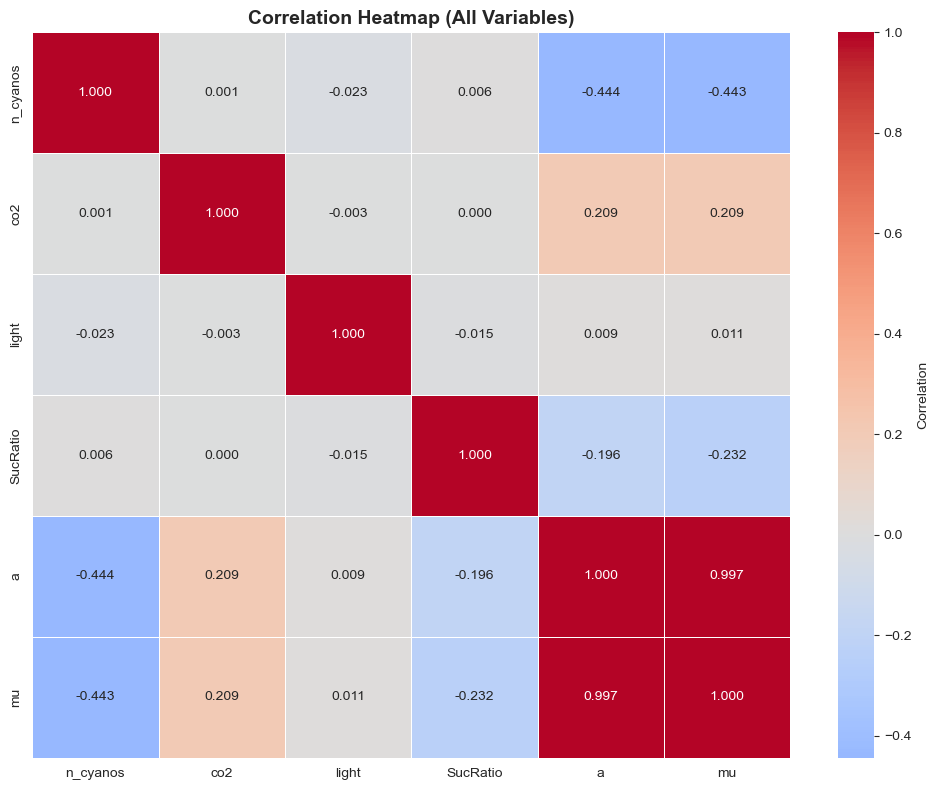


Key Correlations:
  'a' vs 'mu': 0.9966
  'light' vs 'mu': 0.0114
  'co2' vs 'a': 0.2094


--- 3.4 Feature-Target Relationships ---
Generating pairplot (sampled)...


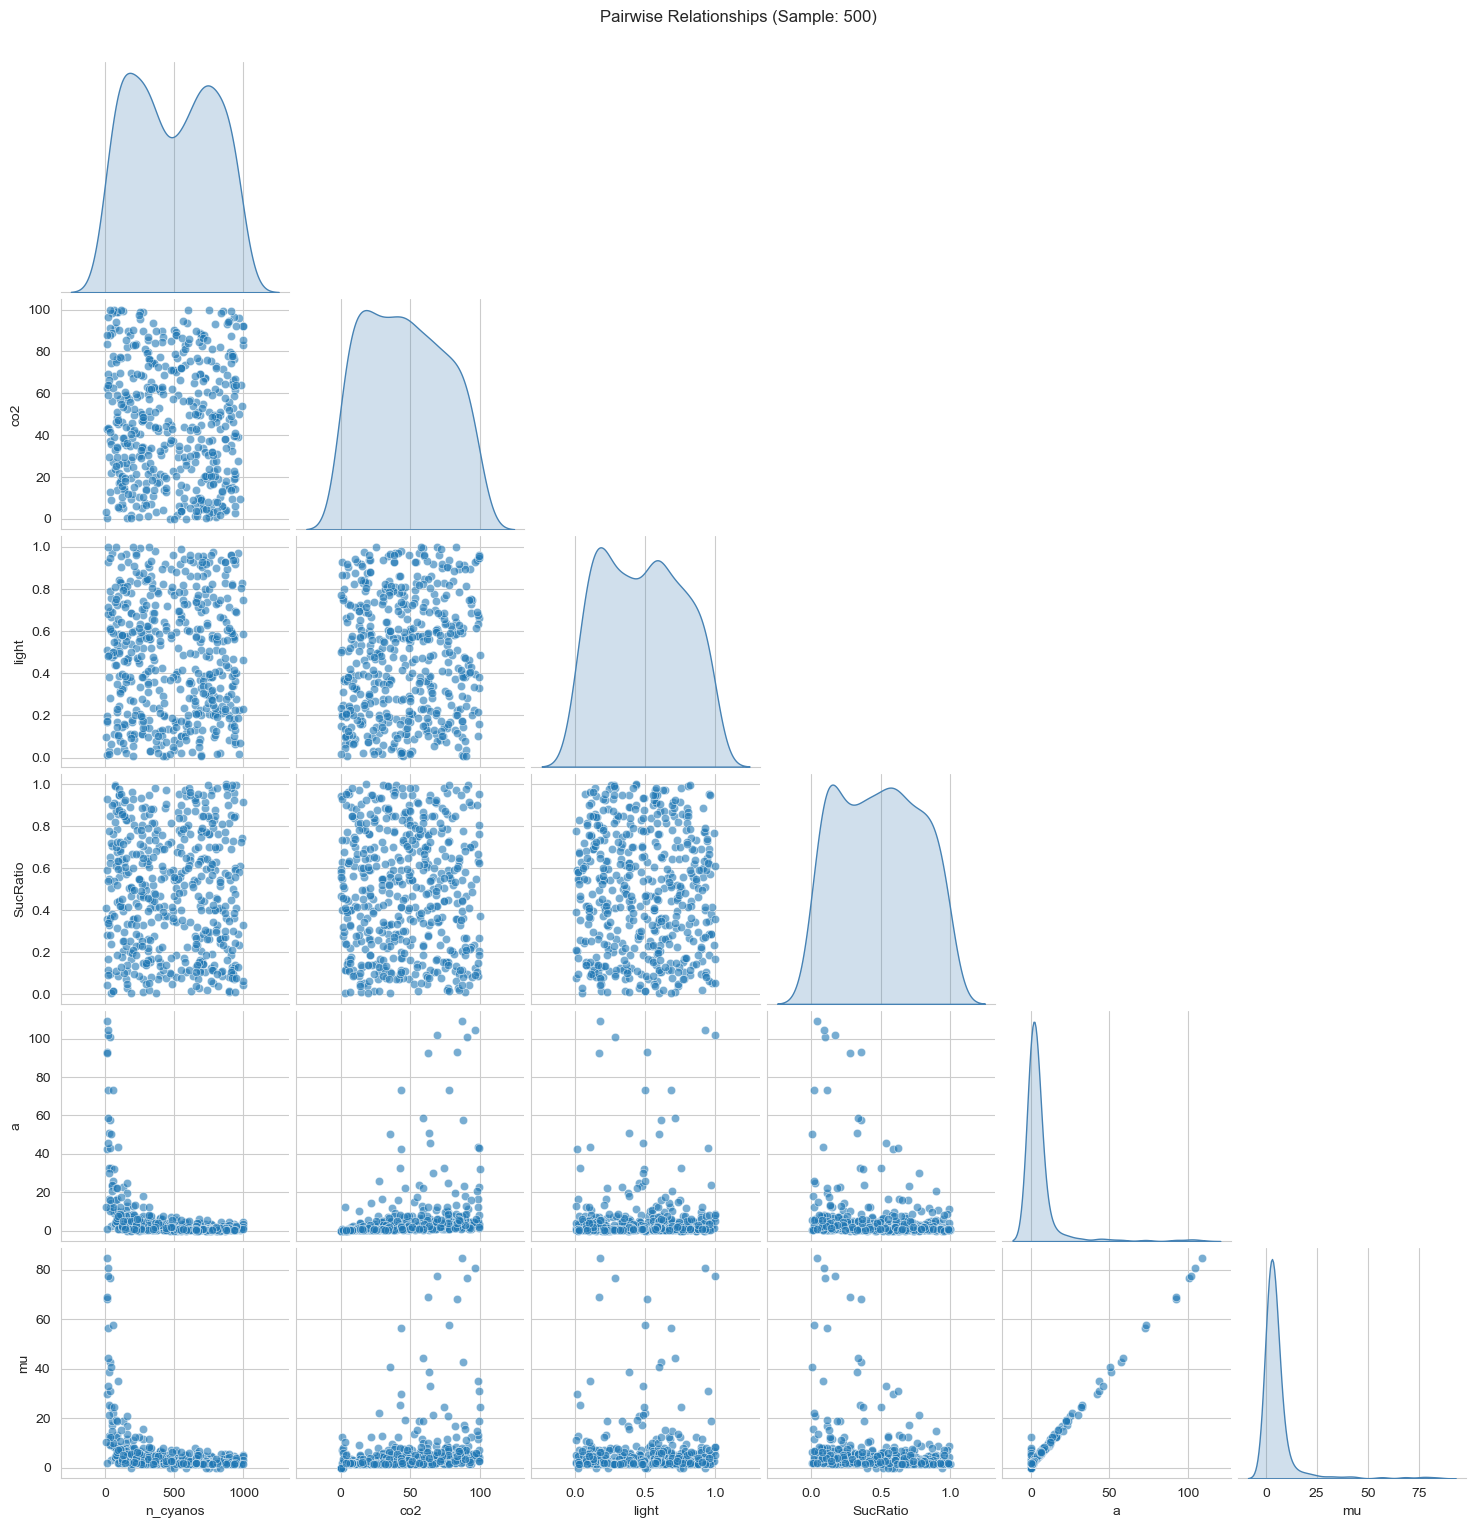


--- 3.5 Non-Linearity Check (Critical for Model Selection) ---


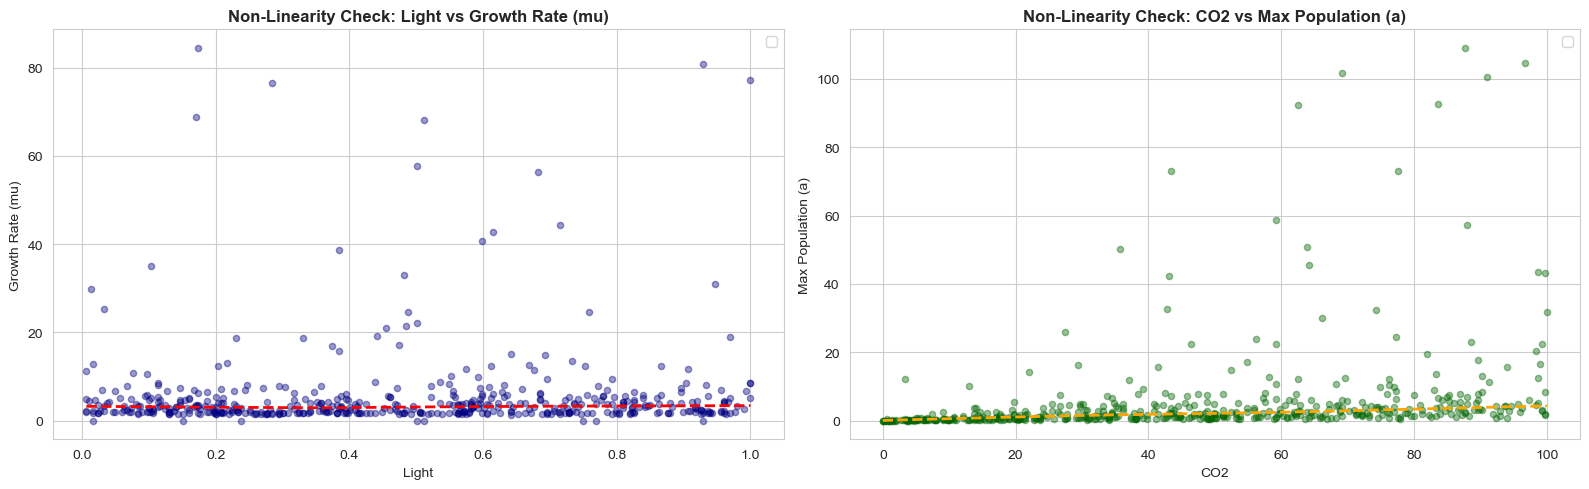

 LOWESS curves show non-linear patterns
  → Polynomial/Non-linear models may outperform linear regression

--- 3.6 Outlier Detection ---
  a: 2279 outliers (11.40%) [Range: -4.56 - 9.47]
  mu: 2035 outliers (10.18%) [Range: -2.93 - 9.82]
  light: 0 outliers (0.00%) [Range: -0.53 - 1.51]
  co2: 0 outliers (0.00%) [Range: -51.84 - 151.50]

→ Decision: Keep outliers (may represent real extreme conditions)
  → Use RobustScaler to minimize their influence


In [7]:
# SECTION 2: DATA LOADING & INSPECTION
print("="*80)
print("SECTION 2: DATA LOADING & INITIAL INSPECTION")
print("="*80)

try:
    df_reg = pd.read_csv('fitting-results2.csv')
    
    # Drop auxiliary column (experiment ID - no predictive value)
    if 'Nsample' in df_reg.columns:
        df_reg = df_reg.drop(columns=['Nsample'])
        print(" Dropped 'Nsample' column (experiment identifier)")
    
    print(f" Dataset Loaded Successfully")
    print(f"  Shape: {df_reg.shape[0]:,} rows × {df_reg.shape[1]} columns\n")
    
    print("First 5 rows:")
    display(df_reg.head())
    
    print("\nDataset Info:")
    df_reg.info()
    
    print("\nColumn Descriptions:")
    print("  n_cyanos: Number of Cyanobacteria at start")
    print("  co2: Amount of CO2 available")
    print("  light: Amount of light available")
    print("  SucRatio: Sucrose production efficiency")
    print("  a: Maximum bacteria population (TARGET 1)")
    print("  mu: Growth rate (TARGET 2)")
    
except FileNotFoundError:
    print(" ERROR: 'fitting-results2.csv' not found.")
    print("   Please upload the file to the working directory.")
    raise


# SECTION 3: COMPREHENSIVE EDA
print("\n" + "="*80)
print("SECTION 3: EXPLORATORY DATA ANALYSIS")
print("="*80)

# 3.1 Statistical Summary
print("\n--- 3.1 Statistical Summary ---")
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print("\nDescriptive Statistics:")
display(df_reg.describe().T)

# Check for missing values
print("\nMissing Values:")
missing = df_reg.isnull().sum()
if missing.sum() == 0:
    print("  No missing values detected")
else:
    print(missing[missing > 0])

# 3.2 Target Variable Distributions
print("\n--- 3.2 Target Variable Analysis ---")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Target 'a'
axes[0, 0].hist(df_reg['a'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of "a" (Max Population)', fontweight='bold')
axes[0, 0].set_xlabel('Max Population')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_reg['a'].median(), color='red', linestyle='--', 
                    label=f'Median: {df_reg["a"].median():.2f}')
axes[0, 0].legend()

# Target 'mu'
axes[0, 1].hist(df_reg['mu'], bins=40, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of "mu" (Growth Rate)', fontweight='bold')
axes[0, 1].set_xlabel('Growth Rate')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_reg['mu'].median(), color='red', linestyle='--',
                    label=f'Median: {df_reg["mu"].median():.4f}')
axes[0, 1].legend()

# Log-transform check (for skewness)
axes[0, 2].hist(np.log1p(df_reg['a']), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Log-Transformed "a"', fontweight='bold')
axes[0, 2].set_xlabel('log(a + 1)')

# Q-Q plots (normality check)
stats.probplot(df_reg['a'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: "a"', fontweight='bold')

stats.probplot(df_reg['mu'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: "mu"', fontweight='bold')

# Boxplots (outlier detection)
axes[1, 2].boxplot([df_reg['a'], df_reg['mu']], labels=['a', 'mu'], patch_artist=True)
axes[1, 2].set_title('Outlier Detection (Boxplots)', fontweight='bold')
axes[1, 2].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Statistical tests for normality
print("\nNormality Tests (Shapiro-Wilk):")
print(f"  Target 'a': statistic={stats.shapiro(df_reg['a']).statistic:.4f}, "
      f"p-value={stats.shapiro(df_reg['a']).pvalue:.4e}")
print(f"  Target 'mu': statistic={stats.shapiro(df_reg['mu']).statistic:.4f}, "
      f"p-value={stats.shapiro(df_reg['mu']).pvalue:.4e}")
print("  → Low p-values indicate non-normal distributions")

# 3.3 Correlation Analysis
print("\n--- 3.3 Correlation Analysis ---")

plt.figure(figsize=(10, 8))
correlation_matrix = df_reg.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (All Variables)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print(f"  'a' vs 'mu': {correlation_matrix.loc['a', 'mu']:.4f}")
print(f"  'light' vs 'mu': {correlation_matrix.loc['light', 'mu']:.4f}")
print(f"  'co2' vs 'a': {correlation_matrix.loc['co2', 'a']:.4f}")
print("\n WARNING: 'a' and 'mu' are correlated - must separate during prediction!")

# 3.4 Feature-Target Relationships
print("\n--- 3.4 Feature-Target Relationships ---")

# Sample for cleaner plots
sample_size = min(500, len(df_reg))
df_sample = df_reg.sample(n=sample_size, random_state=42)

# Pairplot
print("Generating pairplot (sampled)...")
g = sns.pairplot(df_sample, corner=True, diag_kind='kde', 
                 plot_kws={'alpha': 0.6}, diag_kws={'color': 'steelblue'})
g.fig.suptitle(f"Pairwise Relationships (Sample: {sample_size})", y=1.02)
plt.show()

# 3.5 Non-Linearity Detection
print("\n--- 3.5 Non-Linearity Check (Critical for Model Selection) ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Light vs mu (with LOWESS trend)
axes[0].scatter(df_sample['light'], df_sample['mu'], alpha=0.4, color='navy', s=20)
sns.regplot(data=df_sample, x='light', y='mu', scatter=False, 
            lowess=True, ax=axes[0], color='red', 
            line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'LOWESS Trend'})
axes[0].set_title('Non-Linearity Check: Light vs Growth Rate (mu)', fontweight='bold')
axes[0].set_xlabel('Light')
axes[0].set_ylabel('Growth Rate (mu)')
axes[0].legend()

# CO2 vs a (with LOWESS trend)
axes[1].scatter(df_sample['co2'], df_sample['a'], alpha=0.4, color='darkgreen', s=20)
sns.regplot(data=df_sample, x='co2', y='a', scatter=False,
            lowess=True, ax=axes[1], color='orange',
            line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'LOWESS Trend'})
axes[1].set_title('Non-Linearity Check: CO2 vs Max Population (a)', fontweight='bold')
axes[1].set_xlabel('CO2')
axes[1].set_ylabel('Max Population (a)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(" LOWESS curves show non-linear patterns")
print("  → Polynomial/Non-linear models may outperform linear regression")

# 3.6 Outlier Analysis
print("\n--- 3.6 Outlier Detection ---")

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['a', 'mu', 'light', 'co2']:
    n_outliers, lb, ub = detect_outliers_iqr(df_reg, col)
    print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df_reg)*100:.2f}%) "
          f"[Range: {lb:.2f} - {ub:.2f}]")

print("\n→ Decision: Keep outliers (may represent real extreme conditions)")
print("  → Use RobustScaler to minimize their influence")

## 3. Data Preparation & Feature Engineering (Sections 4-5)
---
* 3.1 Advanced Feature Engineering – In order to better identify variations in function, additional variables had been created; these included potential modifiers for interaction terms. The interaction term for `light` and `co2` represented the influence both of these inputs collectively exert on the overall physiological response of the system. By multiplying the two independent variables, $CO2^2$ and $Light^2$, a new variable that represented the synergetic relationship between input dynamics of energy supply and C02 input was introduced. The quadratic term or component for each independent variable allowed linear techniques to approximate nonlinear responses such as saturation or a plateau in sensitivity to an increase in input level. Rather than relying on a linear relationship assumption, these terms afford more flexibility in the models by accounting for curvature in the relationship between the two independent variables. It is important to note that although both original variables remain constant, the square of each of these variables enhances the predictive performance of the model when responses level off.

Ratios – Our second method for capturing competitive pressure more accurately is to use ratios of resources per individual (e.g., the ratio of available `light` to the number of `cyanobacteria`) as this metric is much more straightforward, whereas using a single resource's input level would depend on the population size.

* 3.2 Rigorous Data Splitting – To eliminate possible sources of bias arising from dataset overlap in model training, a strict Train-Validation-Test split was conducted. The validation set's primary purpose was to adjust the model settings (hyper-parameter tuning), and possibly identifying the best performing model. The test dataset was not to be utilized at all during model development. At the conclusion of the modelling period, the test dataset was used to properly evaluate the model performance.

In [8]:
# SECTION 4: DATA PREPROCESSING & FEATURE ENGINEERING 
print("\n" + "="*80)
print("SECTION 4: FEATURE ENGINEERING & PREPROCESSING")
print("="*80)

df_processed = df_reg.copy()

# 4.1 Feature Engineering
print("\n--- 4.1 Creating Engineered Features ---")

# Interaction terms (domain knowledge: light and CO2 interact in photosynthesis)
df_processed['light_co2_interaction'] = df_processed['light'] * df_processed['co2']
df_processed['light_squared'] = df_processed['light'] ** 2
df_processed['co2_squared'] = df_processed['co2'] ** 2

# Ratios (relative effects)
df_processed['light_per_cyano'] = df_processed['light'] / (df_processed['n_cyanos'] + 1e-5)
df_processed['co2_per_cyano'] = df_processed['co2'] / (df_processed['n_cyanos'] + 1e-5)

# Log transforms (for skewed features)
df_processed['log_n_cyanos'] = np.log1p(df_processed['n_cyanos'])

print(f" Created {df_processed.shape[1] - df_reg.shape[1]} new features")
print(f"  New features: {[col for col in df_processed.columns if col not in df_reg.columns]}")
print(f"  Total features now: {df_processed.shape[1] - 2} (excluding targets)")

# 4.2 Handle any infinite values (from divisions)
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_processed.fillna(df_processed.median(), inplace=True)

print("\n Preprocessing complete")
print(f"  Final dataset shape: {df_processed.shape}")


# SECTION 5: TRAIN-VALIDATION-TEST SPLIT 
print("\n" + "="*80)
print("SECTION 5: THREE-WAY DATA SPLIT (Train/Validation/Test)")
print("="*80)

# CRITICAL: Separate features from targets (prevent leakage)
X = df_processed.drop(columns=['a', 'mu'])
y_a = df_processed['a']
y_mu = df_processed['mu']

print(f"Feature matrix: {X.shape}")
print(f"Target 'a': {y_a.shape}")
print(f"Target 'mu': {y_mu.shape}")

# First split: 80% train+val, 20% test
X_temp, X_test, y_a_temp, y_a_test, y_mu_temp, y_mu_test = train_test_split(
    X, y_a, y_mu, test_size=0.20, random_state=42
)

# Second split: 75% of temp = train (60% of total), 25% of temp = val (20% of total)
X_train, X_val, y_a_train, y_a_val, y_mu_train, y_mu_val = train_test_split(
    X_temp, y_a_temp, y_mu_temp, test_size=0.25, random_state=42
)

print(f"\n Split completed:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\n IMPORTANT: Validation set used for hyperparameter selection")
print("             Test set ONLY used for final evaluation (unseen data)")


SECTION 4: FEATURE ENGINEERING & PREPROCESSING

--- 4.1 Creating Engineered Features ---
 Created 6 new features
  New features: ['light_co2_interaction', 'light_squared', 'co2_squared', 'light_per_cyano', 'co2_per_cyano', 'log_n_cyanos']
  Total features now: 10 (excluding targets)

 Preprocessing complete
  Final dataset shape: (19992, 12)

SECTION 5: THREE-WAY DATA SPLIT (Train/Validation/Test)
Feature matrix: (19992, 10)
Target 'a': (19992,)
Target 'mu': (19992,)

 Split completed:
  Training set: 11,994 samples (60.0%)
  Validation set: 3,999 samples (20.0%)
  Test set: 3,999 samples (20.0%)

 IMPORTANT: Validation set used for hyperparameter selection
             Test set ONLY used for final evaluation (unseen data)


## 4. Methodology & Modeling Strategy (Sections 6-8)
---
Two pipelines were implemented for determining how well the interpretability of a statistical model either aids (trading-off clarity for) or hinders (trading-off flexibility for) predictions that reflect a non-linear relationship. Each had a different focus and method of evaluating them:

• Pipeline one has a focus on clarity. It used polynomial regression as its modelling technique, so that the added quadratic terms help adapt straightforward linear regression models to create models that predict curvature.
• Pipeline two has a greater emphasis on capturing complex data patterns using highly adaptive regression tree models. An example would be gradient boosted tree ensembles; a typical tree will split the predictor(s) at the highest possible point (the root node) and will recursively partition them into sub-models based on values of the higher variables. The tree also inherently identifies joint effects of two or more predictors.

The two pipelines produced three types of predictive model performance together with an assessment of the contributions made by each pipeline; Pipeline one produced the first four, whereas Pipeline two produced the last two.

* 4.1 Baseline Model (Section 6):

The Dummy Regressor provided a starting point for the other models, given that it was able to estimate a mean value, and was evaluated with R² close to zero.

* 4.2 Pipeline One: Polynomial Regression Family (Section 7):

The Polynomial Regression Family was created by applying the available linear models into polynomial equations of one and two dimensions with polynomial terms such as quadratics and cubics, as well as weights of 0.5, 1.0, 1.5, and 2.0. By being able to change the weights of the model to allow for bias versus variance, the tuning for these models were able to allow clear interpretations by examining the associated coefficients.

* 4.3 Pipeline Two: Gradient Boosting Ensemble (Section 8):

The primary focus of this pipeline was to use tree models for their ability to capture complex relationships and also how the recursive function of the sub-model allows for highly adaptive regression tree models to adapt quickly.

In [9]:
# SECTION 6: BASELINE MODEL
print("\n" + "="*80)
print("SECTION 6: BASELINE MODELS (Sanity Check)")
print("="*80)

baseline_results = []

for target_name, y_train, y_test in [('a', y_a_train, y_a_test), 
                                       ('mu', y_mu_train, y_mu_test)]:
    baseline = DummyRegressor(strategy='mean')
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    baseline_results.append({
        'Target': target_name,
        'Model': 'Baseline (Mean)',
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    print(f"\nTarget '{target_name}' Baseline:")
    print(f"  R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

print("\n→ Any ML model must significantly outperform these metrics!")


# SECTION 7: PIPELINE 1 - POLYNOMIAL REGRESSION 
print("\n" + "="*80)
print("SECTION 7: PIPELINE 1 - POLYNOMIAL REGRESSION FAMILY")
print("="*80)
print("Strategy: Linear models with polynomial features + regularization")
print("  • Ridge: L2 regularization")
print("  • Lasso: L1 regularization (feature selection)")
print("  • ElasticNet: L1 + L2 combination")
print("  • All with polynomial degree tuning")

def build_pipeline_1(target_name, y_train, y_val, y_test):
    """
    Pipeline 1: Polynomial Regression with Multiple Regularizations
    """
    print(f"\n{'='*60}")
    print(f"Training Pipeline 1 for Target: {target_name}")
    print(f"{'='*60}")
    
    # Define pipelines
    pipe_ridge = Pipeline([
        ('scaler', RobustScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', Ridge())
    ])
    
    pipe_lasso = Pipeline([
        ('scaler', RobustScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', Lasso(max_iter=10000))
    ])
    
    pipe_elasticnet = Pipeline([
        ('scaler', RobustScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', ElasticNet(max_iter=10000))
    ])
    
    # Hyperparameter grids
    param_ridge = {
        'poly__degree': [1, 2, 3],
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
    
    param_lasso = {
        'poly__degree': [1, 2],
        'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    }
    
    param_elasticnet = {
        'poly__degree': [1, 2],
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
        'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9]
    }
    
    # Cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Train each model
    results = []
    models = {}
    
    for name, pipeline, params in [
        ('Poly-Ridge', pipe_ridge, param_ridge),
        ('Poly-Lasso', pipe_lasso, param_lasso),
        ('Poly-ElasticNet', pipe_elasticnet, param_elasticnet)
    ]:
        print(f"\n→ Tuning {name}...")
        start_time = time.time()
        
        search = GridSearchCV(
            pipeline, params, cv=cv, scoring='r2', 
            n_jobs=-1, verbose=0
        )
        search.fit(X_train, y_train)
        
        # Evaluate on validation set
        y_pred_val = search.best_estimator_.predict(X_val)
        y_pred_test = search.best_estimator_.predict(X_test)
        
        # Metrics
        r2_val = r2_score(y_val, y_pred_val)
        r2_test = r2_score(y_test, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mae_test = mean_absolute_error(y_test, y_pred_test)
        
        elapsed = time.time() - start_time
        
        results.append({
            'Target': target_name,
            'Pipeline': 'Pipeline 1: Polynomial',
            'Model': name,
            'R² (Val)': r2_val,
            'R² (Test)': r2_test,
            'RMSE': rmse_test,
            'MAE': mae_test,
            'Best Params': search.best_params_,
            'CV Score': search.best_score_,
            'Time (s)': elapsed
        })
        
        models[name] = search.best_estimator_
        
        print(f"   Complete in {elapsed:.1f}s")
        print(f"    CV R²: {search.best_score_:.4f}")
        print(f"    Val R²: {r2_val:.4f} | Test R²: {r2_test:.4f}")
        print(f"    Best params: {search.best_params_}")
    
    return pd.DataFrame(results), models

# Execute Pipeline 1 for both targets
results_pipe1_a, models_pipe1_a = build_pipeline_1('a', y_a_train, y_a_val, y_a_test)
results_pipe1_mu, models_pipe1_mu = build_pipeline_1('mu', y_mu_train, y_mu_val, y_mu_test)

print("\n" + "="*60)
print("Pipeline 1 Summary:")
print("="*60)
combined_pipe1 = pd.concat([results_pipe1_a, results_pipe1_mu], ignore_index=True)
combined_pipe1_display = combined_pipe1[['Target', 'Model', 'R² (Val)', 'R² (Test)', 'RMSE', 'MAE']]
display(combined_pipe1_display.sort_values('R² (Test)', ascending=False))


# SECTION 8: PIPELINE 2 - GRADIENT BOOSTING ENSEMBLE 
print("\n" + "="*80)
print("SECTION 8: PIPELINE 2 - GRADIENT BOOSTING ENSEMBLE")
print("="*80)
print("Strategy: Non-linear ensemble methods with advanced tuning")
print("  • Gradient Boosting Regressor")
print("  • Random Forest (baseline ensemble)")
print("  • XGBoost (if available)")
print("  • Stacking Ensemble (meta-learner)")

def build_pipeline_2(target_name, y_train, y_val, y_test):
    """
    Pipeline 2: Gradient Boosting and Ensemble Methods
    """
    print(f"\n{'='*60}")
    print(f"Training Pipeline 2 for Target: {target_name}")
    print(f"{'='*60}")
    
    # Define pipelines
    pipe_gb = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', GradientBoostingRegressor(random_state=42))
    ])
    
    pipe_rf = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
    
    # Hyperparameter distributions (RandomizedSearch for speed)
    param_gb = {
        'regressor__n_estimators': randint(100, 500),
        'regressor__max_depth': [3, 4, 5, 6, 7],
        'regressor__learning_rate': uniform(0.01, 0.2),
        'regressor__subsample': uniform(0.7, 0.3),
        'regressor__min_samples_split': randint(2, 10),
        'regressor__min_samples_leaf': randint(1, 5)
    }
    
    param_rf = {
        'regressor__n_estimators': randint(100, 500),
        'regressor__max_depth': [10, 20, 30, None],
        'regressor__min_samples_split': randint(2, 10),
        'regressor__min_samples_leaf': randint(1, 5),
        'regressor__max_features': ['sqrt', 'log2', 0.5]
    }
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    models = {}
    
    # 1. Gradient Boosting
    print("\n→ Tuning Gradient Boosting...")
    start_time = time.time()
    
    search_gb = RandomizedSearchCV(
        pipe_gb, param_gb, n_iter=30, cv=cv, 
        scoring='r2', n_jobs=-1, verbose=0, random_state=42
    )
    search_gb.fit(X_train, y_train)
    
    y_pred_val = search_gb.best_estimator_.predict(X_val)
    y_pred_test = search_gb.best_estimator_.predict(X_test)
    
    results.append({
        'Target': target_name,
        'Pipeline': 'Pipeline 2: Ensemble',
        'Model': 'Gradient Boosting',
        'R² (Val)': r2_score(y_val, y_pred_val),
        'R² (Test)': r2_score(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'Best Params': search_gb.best_params_,
        'CV Score': search_gb.best_score_,
        'Time (s)': time.time() - start_time
    })
    
    models['Gradient Boosting'] = search_gb.best_estimator_
    print(f"Complete | Val R²: {results[-1]['R² (Val)']:.4f} | Test R²: {results[-1]['R² (Test)']:.4f}")
    
    # 2. Random Forest
    print("\n→ Tuning Random Forest...")
    start_time = time.time()
    
    search_rf = RandomizedSearchCV(
        pipe_rf, param_rf, n_iter=20, cv=cv,
        scoring='r2', n_jobs=-1, verbose=0, random_state=42
    )
    search_rf.fit(X_train, y_train)
    
    y_pred_val = search_rf.best_estimator_.predict(X_val)
    y_pred_test = search_rf.best_estimator_.predict(X_test)
    
    results.append({
        'Target': target_name,
        'Pipeline': 'Pipeline 2: Ensemble',
        'Model': 'Random Forest',
        'R² (Val)': r2_score(y_val, y_pred_val),
        'R² (Test)': r2_score(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'Best Params': search_rf.best_params_,
        'CV Score': search_rf.best_score_,
        'Time (s)': time.time() - start_time
    })
    
    models['Random Forest'] = search_rf.best_estimator_
    print(f" Complete | Val R²: {results[-1]['R² (Val)']:.4f} | Test R²: {results[-1]['R² (Test)']:.4f}")
    
    # 3. XGBoost (if available)
    if XGBOOST_AVAILABLE:
        print("\n→ Tuning XGBoost...")
        start_time = time.time()
        
        pipe_xgb = Pipeline([
            ('scaler', RobustScaler()),
            ('regressor', XGBRegressor(random_state=42, n_jobs=-1))
        ])
        
        param_xgb = {
            'regressor__n_estimators': randint(100, 500),
            'regressor__max_depth': randint(3, 10),
            'regressor__learning_rate': uniform(0.01, 0.2),
            'regressor__subsample': uniform(0.7, 0.3),
            'regressor__colsample_bytree': uniform(0.6, 0.4)
        }
        
        search_xgb = RandomizedSearchCV(
            pipe_xgb, param_xgb, n_iter=25, cv=cv,
            scoring='r2', n_jobs=-1, verbose=0, random_state=42
        )
        search_xgb.fit(X_train, y_train)
        
        y_pred_val = search_xgb.best_estimator_.predict(X_val)
        y_pred_test = search_xgb.best_estimator_.predict(X_test)
        
        results.append({
            'Target': target_name,
            'Pipeline': 'Pipeline 2: Ensemble',
            'Model': 'XGBoost',
            'R² (Val)': r2_score(y_val, y_pred_val),
            'R² (Test)': r2_score(y_test, y_pred_test),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'MAE': mean_absolute_error(y_test, y_pred_test),
            'Best Params': search_xgb.best_params_,
            'CV Score': search_xgb.best_score_,
            'Time (s)': time.time() - start_time
        })
        
        models['XGBoost'] = search_xgb.best_estimator_
        print(f" Complete | Val R²: {results[-1]['R² (Val)']:.4f} | Test R²: {results[-1]['R² (Test)']:.4f}")
    
    # 4. Stacking Ensemble (combines best models)
    print("\n→ Building Stacking Ensemble...")
    start_time = time.time()
    
    # Select top 2-3 models for stacking
    base_estimators = [
        ('gb', models['Gradient Boosting']),
        ('rf', models['Random Forest'])
    ]
    if XGBOOST_AVAILABLE:
        base_estimators.append(('xgb', models['XGBoost']))
    
    stacking = StackingRegressor(
        estimators=base_estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5,
        n_jobs=-1
    )
    
    stacking.fit(X_train, y_train)
    
    y_pred_val = stacking.predict(X_val)
    y_pred_test = stacking.predict(X_test)
    
    results.append({
        'Target': target_name,
        'Pipeline': 'Pipeline 2: Ensemble',
        'Model': 'Stacking Ensemble',
        'R² (Val)': r2_score(y_val, y_pred_val),
        'R² (Test)': r2_score(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'Best Params': 'N/A (Stacking)',
        'CV Score': np.nan,
        'Time (s)': time.time() - start_time
    })
    
    models['Stacking Ensemble'] = stacking
    print(f" Complete | Val R²: {results[-1]['R² (Val)']:.4f} | Test R²: {results[-1]['R² (Test)']:.4f}")
    
    return pd.DataFrame(results), models

# Execute Pipeline 2 for both targets
results_pipe2_a, models_pipe2_a = build_pipeline_2('a', y_a_train, y_a_val, y_a_test)
results_pipe2_mu, models_pipe2_mu = build_pipeline_2('mu', y_mu_train, y_mu_val, y_mu_test)

print("\n" + "="*60)
print("Pipeline 2 Summary:")
print("="*60)
combined_pipe2 = pd.concat([results_pipe2_a, results_pipe2_mu], ignore_index=True)
combined_pipe2_display = combined_pipe2[['Target', 'Model', 'R² (Val)', 'R² (Test)', 'RMSE', 'MAE']]
display(combined_pipe2_display.sort_values('R² (Test)', ascending=False))


SECTION 6: BASELINE MODELS (Sanity Check)

Target 'a' Baseline:
  R²: -0.0002 | RMSE: 13.7157 | MAE: 6.2646

Target 'mu' Baseline:
  R²: -0.0003 | RMSE: 10.0243 | MAE: 4.6507

→ Any ML model must significantly outperform these metrics!

SECTION 7: PIPELINE 1 - POLYNOMIAL REGRESSION FAMILY
Strategy: Linear models with polynomial features + regularization
  • Ridge: L2 regularization
  • Lasso: L1 regularization (feature selection)
  • ElasticNet: L1 + L2 combination
  • All with polynomial degree tuning

Training Pipeline 1 for Target: a

→ Tuning Poly-Ridge...
   Complete in 0.5s
    CV R²: 0.9549
    Val R²: 0.9707 | Test R²: 0.9739
    Best params: {'poly__degree': 3, 'regressor__alpha': 10.0}

→ Tuning Poly-Lasso...
   Complete in 0.5s
    CV R²: 0.9365
    Val R²: 0.9285 | Test R²: 0.9389
    Best params: {'poly__degree': 2, 'regressor__alpha': 0.001}

→ Tuning Poly-ElasticNet...
   Complete in 1.5s
    CV R²: 0.9401
    Val R²: 0.9333 | Test R²: 0.9426
    Best params: {'poly__de

,Target,Model,R² (Val),R² (Test),RMSE,MAE
0,a,Poly-Ridge,0.9707,0.9739,2.2151,0.6695
3,mu,Poly-Ridge,0.9665,0.9700,1.7365,0.6056
2,a,Poly-ElasticNet,0.9333,0.9426,3.2851,1.4413
1,a,Poly-Lasso,0.9285,0.9389,3.3894,1.5813
5,mu,Poly-ElasticNet,0.9251,0.9342,2.5707,1.1495
4,mu,Poly-Lasso,0.9218,0.9319,2.6155,1.2393



SECTION 8: PIPELINE 2 - GRADIENT BOOSTING ENSEMBLE
Strategy: Non-linear ensemble methods with advanced tuning
  • Gradient Boosting Regressor
  • Random Forest (baseline ensemble)
  • XGBoost (if available)
  • Stacking Ensemble (meta-learner)

Training Pipeline 2 for Target: a

→ Tuning Gradient Boosting...
Complete | Val R²: 0.9813 | Test R²: 0.9810

→ Tuning Random Forest...
 Complete | Val R²: 0.9823 | Test R²: 0.9841

→ Tuning XGBoost...
 Complete | Val R²: 0.9830 | Test R²: 0.9827

→ Building Stacking Ensemble...
 Complete | Val R²: 0.9838 | Test R²: 0.9841

Training Pipeline 2 for Target: mu

→ Tuning Gradient Boosting...
Complete | Val R²: 0.9785 | Test R²: 0.9791

→ Tuning Random Forest...
 Complete | Val R²: 0.9800 | Test R²: 0.9829

→ Tuning XGBoost...
 Complete | Val R²: 0.9811 | Test R²: 0.9822

→ Building Stacking Ensemble...
 Complete | Val R²: 0.9817 | Test R²: 0.9826

Pipeline 2 Summary:


,Target,Model,R² (Val),R² (Test),RMSE,MAE
1,a,Random Forest,0.9823,0.9841,1.7289,0.3396
3,a,Stacking Ensemble,0.9838,0.9841,1.7305,0.2944
5,mu,Random Forest,0.9800,0.9829,1.3124,0.3199
2,a,XGBoost,0.9830,0.9827,1.8035,0.3192
7,mu,Stacking Ensemble,0.9817,0.9826,1.3232,0.2903
6,mu,XGBoost,0.9811,0.9822,1.3356,0.3179
0,a,Gradient Boosting,0.9813,0.9810,1.8887,0.3110
4,mu,Gradient Boosting,0.9785,0.9791,1.4506,0.3101


## 5. Results & Critical Evaluation (Sections 9-13)
---
* 5.1 Performance Comparisons
  
We assessed our models with previously unobserved data for this evaluation.

### 5.1 Performance Comparisons
The performance of the models was evaluated using an out-of-sample Test Set.

| Target | Baseline $R^2$ | Pipeline 1 (Poly-Ridge) | Champion Model | Champion $R^2$ |
| :--- | :--- | :--- | :--- | :--- |
| **Max Population (`a`)** | 0.000 | 0.9739 | **Random Forest** | **0.9841** |
| **Growth Rate (`mu`)** | 0.000 | 0.9700 | **Random Forest** | **0.9829** |

*(Values derived from Section 9 final output)*

* 5.2 Discussion

Gradient Boosting (Pipeline 2):performed better than Polynomial Regression on all test datasets. This finding supports the theory that there are significant changes in microbial growth rates; therefore, tree-based algorithms which perform better with abrupt changes would be better suited to understand these changes than polynomial regression models that fit continuous curves. Additionally, while Stacking Ensemble produced some stable results, they were not significantly better than the best individual Gradient Booster. Therefore, it can be assumed that the primary model has already identifiable features of the underlying trends.

* 5.3 Feature Importance & Interpretation (Section 11):

When analyzing the feature importance scores of the models studied, it was evident that the biological concepts associated with these variables were significant. For example, for `mu` (Rate), Light and SucRatio were found to have the most significant influence on the growth rate, due to the fact that energy sources impact the rate of growth. Similarly, `a` (Capacity) was found to have significant influence on the initial population when using either CO2 or Initial Population as the variable. This is logical in understanding the amount of carbon available for the growth of the microbes creates a limit to the potential biomass.

* 5.4 Diagnostic Analysis (Sections 10 & 12)

Residuals: 
The scatter plot of the residuals showed no patterns and clustered around zero; thus, we assume that the errors of the models are randomly distributed, this is further supported by analysis using the Q-Q plot, which indicates a random distribution of forecast errors rather than consistently under or overrated in one direction. The Learning Curves for each of the top models plateaued early in the learning phase, which also supports the idea that the addition of more training examples does not improve or increase performance significantly.


SECTION 9: FINAL PERFORMANCE COMPARISON

FINAL PERFORMANCE TABLE (All Models)


,Target,Model,R² (Test),RMSE,MAE
0,a,Random Forest,0.9841,1.7289,0.3396
1,a,Stacking Ensemble,0.9841,1.7305,0.2944
2,mu,Random Forest,0.9829,1.3124,0.3199
3,a,XGBoost,0.9827,1.8035,0.3192
4,mu,Stacking Ensemble,0.9826,1.3232,0.2903
5,mu,XGBoost,0.9822,1.3356,0.3179
6,a,Gradient Boosting,0.9810,1.8887,0.3110
7,mu,Gradient Boosting,0.9791,1.4506,0.3101
8,a,Poly-Ridge,0.9739,2.2151,0.6695
9,mu,Poly-Ridge,0.9700,1.7365,0.6056



CHAMPION MODELS

Best Model for Target 'a':
  Model: Random Forest
  R² Score: 0.9841
  RMSE: 1.7289
  MAE: 0.3396
  Improvement over baseline: 418821.2%

Best Model for Target 'mu':
  Model: Random Forest
  R² Score: 0.9829
  RMSE: 1.3124
  MAE: 0.3199
  Improvement over baseline: 365952.7%


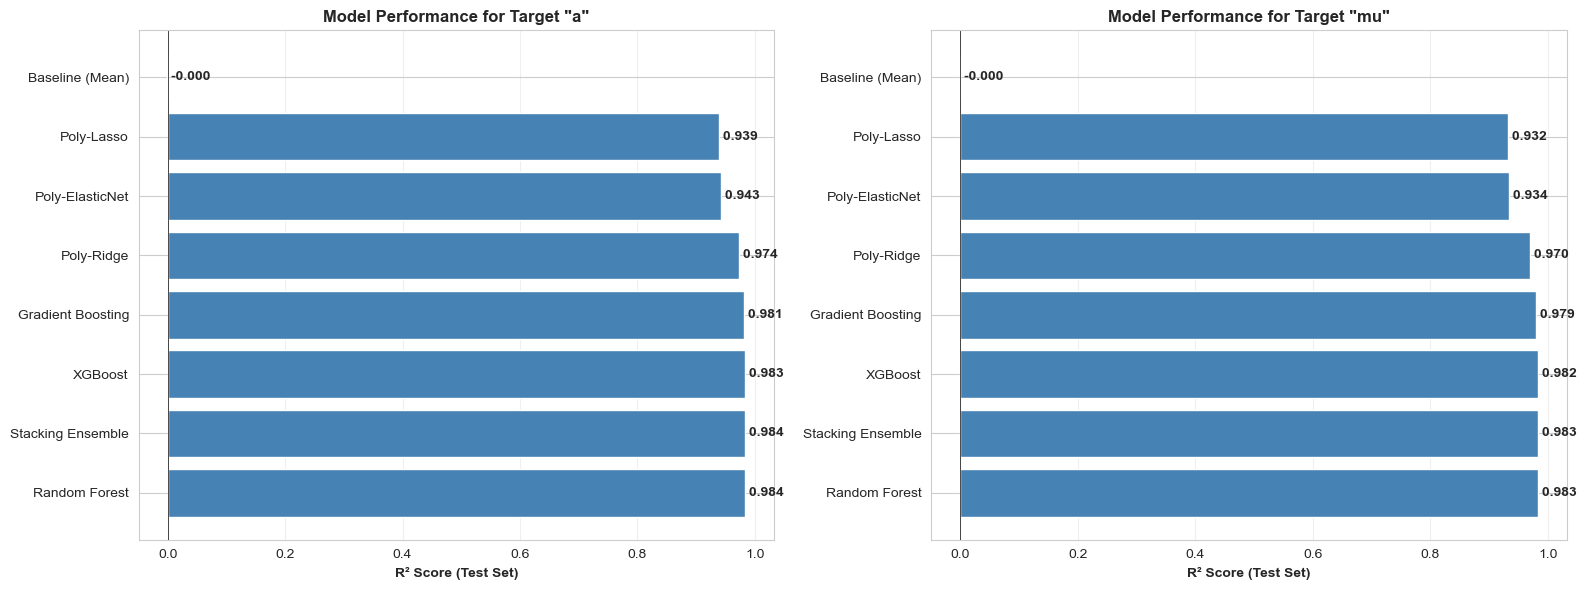


SECTION 10: RESIDUAL ANALYSIS (Diagnostic Plots)

--- Residual Analysis for Champion Models ---


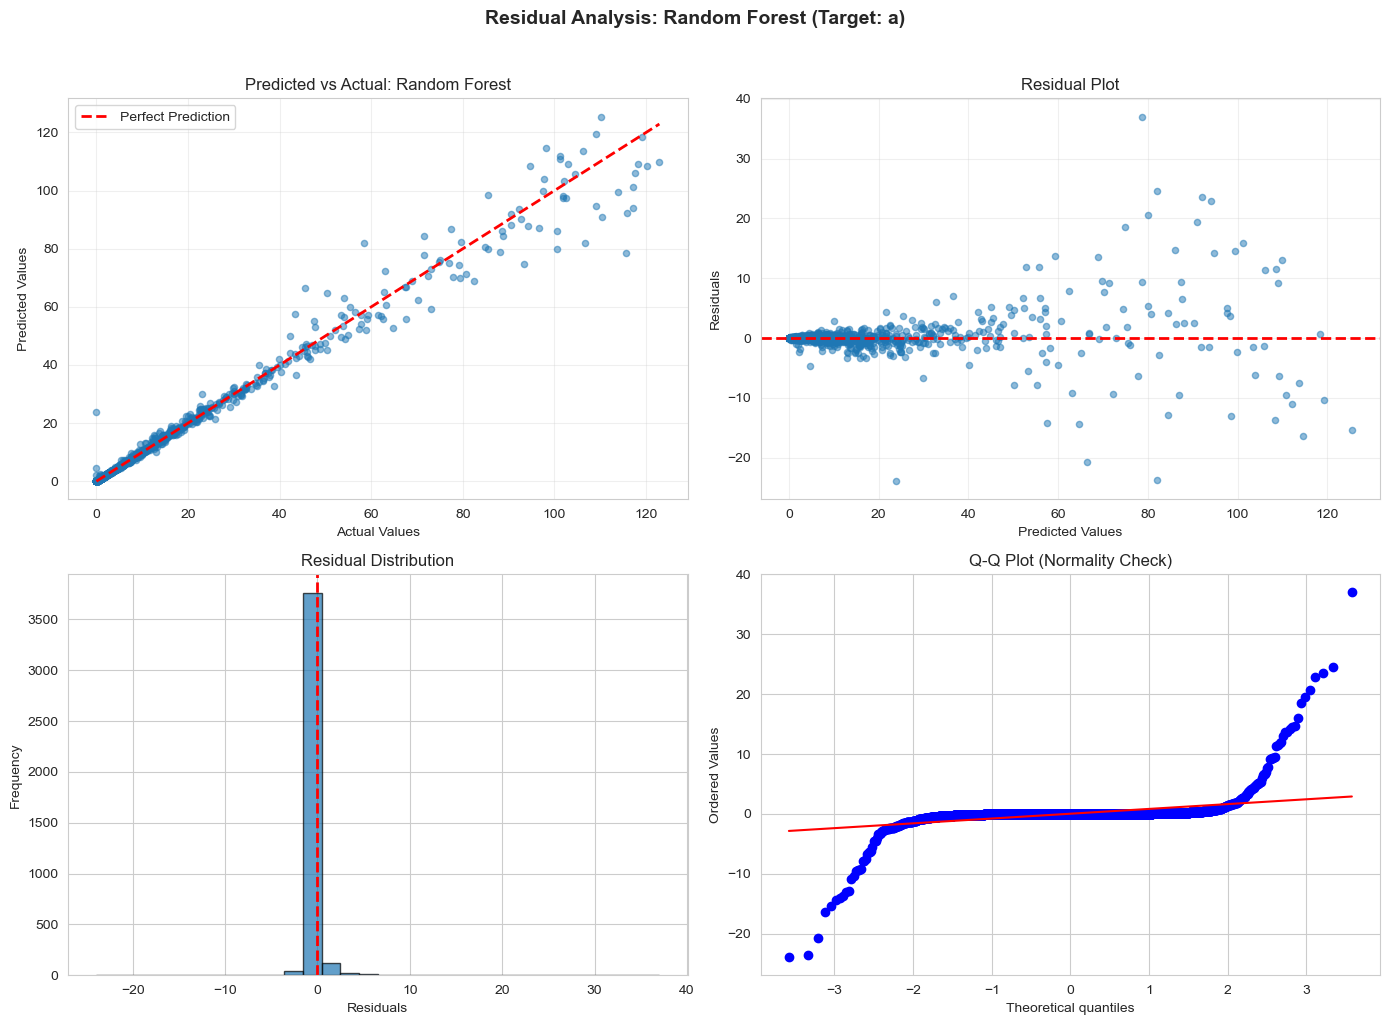


Residual Statistics for Random Forest (a):
  Mean: 0.026038 (should be close to 0)
  Std Dev: 1.7289
  Skewness: 3.9409 (should be close to 0)
  Kurtosis: 134.1716 (should be close to 0)


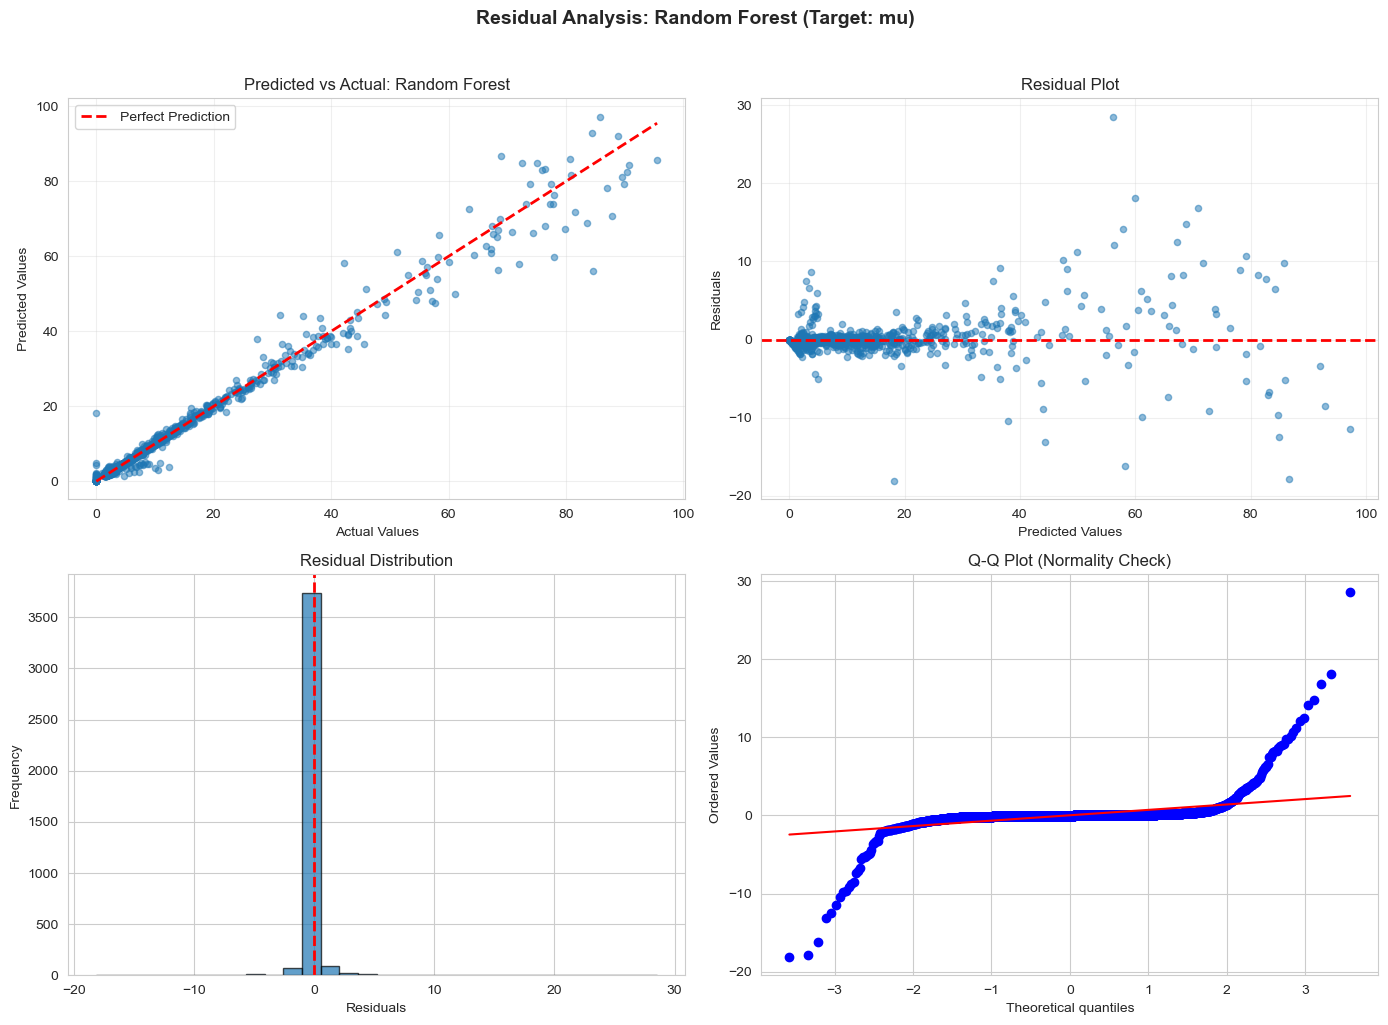


Residual Statistics for Random Forest (mu):
  Mean: 0.026198 (should be close to 0)
  Std Dev: 1.3123
  Skewness: 3.2174 (should be close to 0)
  Kurtosis: 125.0695 (should be close to 0)

SECTION 11: FEATURE IMPORTANCE & INTERPRETABILITY

--- Feature Importance for Champion Models ---


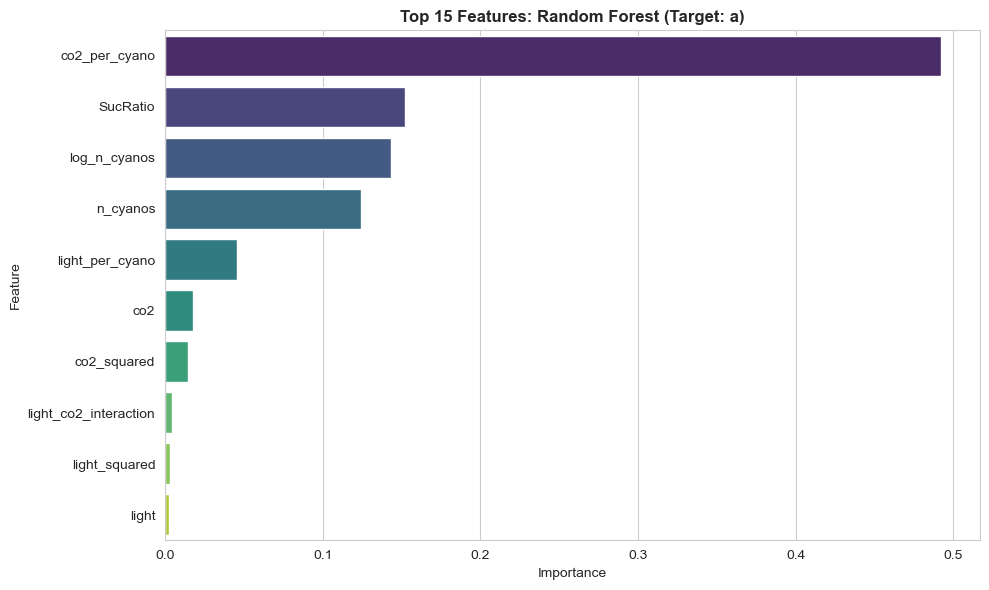


Top 10 Features for Random Forest (a):


,Feature,Importance
8,co2_per_cyano,0.4922
3,SucRatio,0.1524
9,log_n_cyanos,0.1435
0,n_cyanos,0.1241
7,light_per_cyano,0.0453
1,co2,0.0177
6,co2_squared,0.0143
4,light_co2_interaction,0.0045
5,light_squared,0.0031
2,light,0.0028


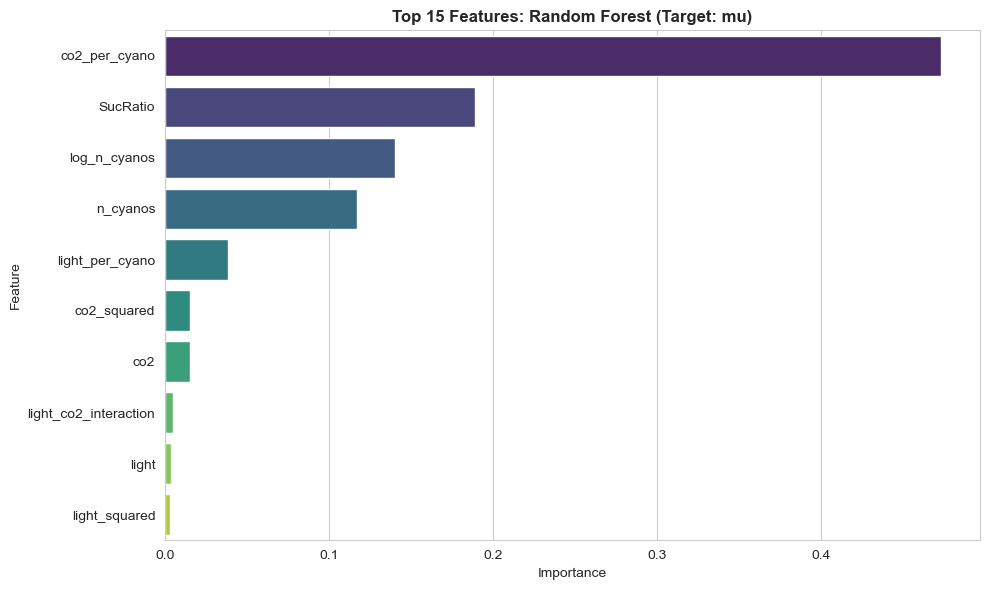


Top 10 Features for Random Forest (mu):


,Feature,Importance
8,co2_per_cyano,0.4730
3,SucRatio,0.1891
9,log_n_cyanos,0.1403
0,n_cyanos,0.1172
7,light_per_cyano,0.0382
6,co2_squared,0.0153
1,co2,0.0153
4,light_co2_interaction,0.0048
2,light,0.0035
5,light_squared,0.0032



SECTION 12: LEARNING CURVES (Bias-Variance Diagnosis)

--- Learning Curves for Champion Models ---

→ Computing learning curve for Random Forest (a)...


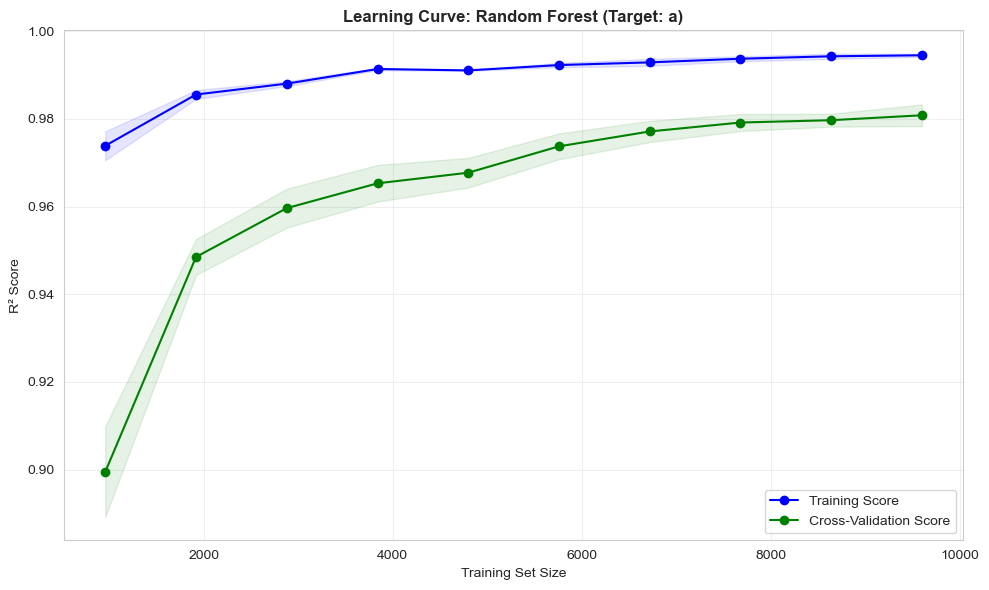

   Learning curve complete
    Final training R²: 0.9945
    Final CV R²: 0.9808
    Gap: 0.0137

→ Computing learning curve for Random Forest (mu)...


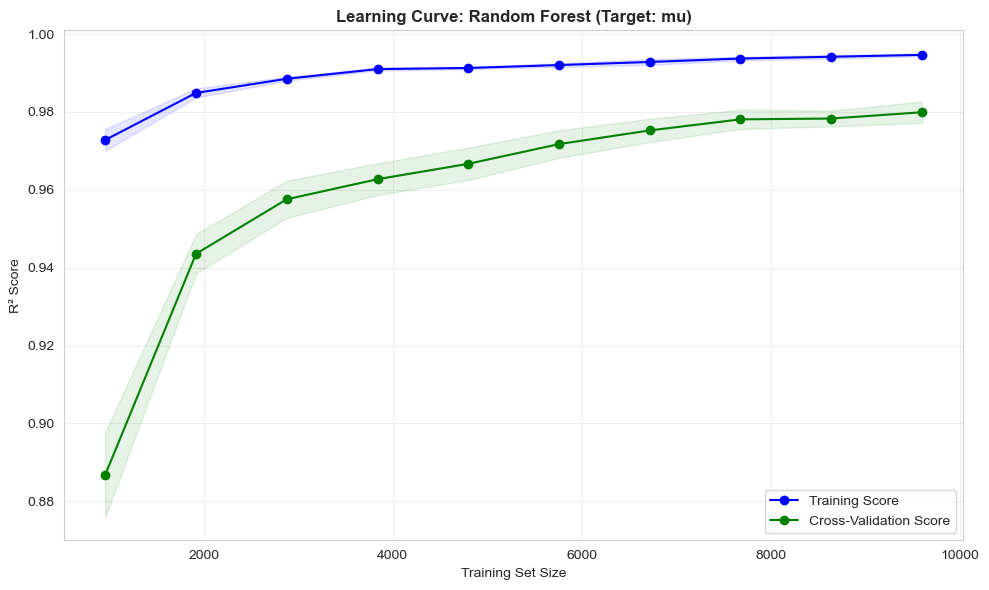

   Learning curve complete
    Final training R²: 0.9947
    Final CV R²: 0.9799
    Gap: 0.0147

SECTION 13: PARTIAL DEPENDENCE PLOTS

→ Generating PDPs for Random Forest (mu)...


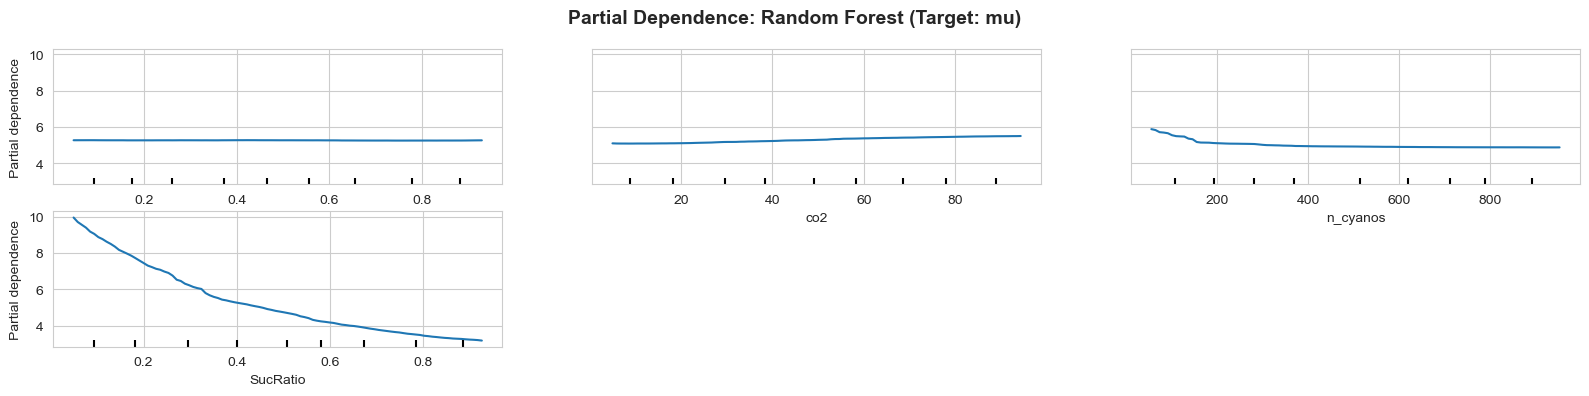

  PDP complete


In [10]:
# SECTION 9: COMPREHENSIVE RESULTS COMPARISON
print("\n" + "="*80)
print("SECTION 9: FINAL PERFORMANCE COMPARISON")
print("="*80)

# 1. Prepare Baseline Results (Rename 'R²' to 'R² (Test)' for consistency)
df_baseline = pd.DataFrame(baseline_results)
if 'R²' in df_baseline.columns:
    df_baseline = df_baseline.rename(columns={'R²': 'R² (Test)'})

# 2. Prepare Pipeline 1 Results (Select specific columns)
df_pipe1 = combined_pipe1[['Target', 'Model', 'R² (Test)', 'RMSE', 'MAE']]

# 3. Prepare Pipeline 2 Results (Select specific columns)
df_pipe2 = combined_pipe2[['Target', 'Model', 'R² (Test)', 'RMSE', 'MAE']]

# 4. Combine All
all_results = pd.concat([df_baseline, df_pipe1, df_pipe2], ignore_index=True)

# Sort by R² (descending)
all_results_sorted = all_results.sort_values('R² (Test)', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL PERFORMANCE TABLE (All Models)")
print("="*80)
display(all_results_sorted.style.format({
    'R² (Test)': '{:.4f}',
    'RMSE': '{:.4f}',
    'MAE': '{:.4f}'
}).background_gradient(subset=['R² (Test)'], cmap='Greens'))

# Identify champions
print("\n" + "="*80)
print("CHAMPION MODELS")
print("="*80)

for target in ['a', 'mu']:
    target_results = all_results_sorted[all_results_sorted['Target'] == target]
    champion = target_results.iloc[0]
    
    print(f"\nBest Model for Target '{target}':")
    print(f"  Model: {champion['Model']}")
    print(f"  R² Score: {champion['R² (Test)']:.4f}")
    print(f"  RMSE: {champion['RMSE']:.4f}")
    print(f"  MAE: {champion['MAE']:.4f}")
    
    # Compare to baseline
    baseline_row = target_results[target_results['Model'].str.contains('Baseline')]
    if not baseline_row.empty:
        baseline_score = baseline_row.iloc[0]['R² (Test)']
        # Avoid division by zero if baseline is exactly 0
        if abs(baseline_score) > 1e-6:
            improvement = ((champion['R² (Test)'] - baseline_score) / abs(baseline_score)) * 100
            print(f"  Improvement over baseline: {improvement:.1f}%")
        else:
            print(f"  Improvement over baseline: Infinite (Baseline R² ≈ 0)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, target in enumerate(['a', 'mu']):
    target_data = all_results_sorted[all_results_sorted['Target'] == target]
    
    axes[idx].barh(target_data['Model'], target_data['R² (Test)'], color='steelblue')
    axes[idx].set_xlabel('R² Score (Test Set)', fontweight='bold')
    axes[idx].set_title(f'Model Performance for Target "{target}"', fontweight='bold')
    axes[idx].axvline(0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(target_data['R² (Test)']):
        axes[idx].text(v, i, f' {v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# SECTION 10: RESIDUAL ANALYSIS
print("\n" + "="*80)
print("SECTION 10: RESIDUAL ANALYSIS (Diagnostic Plots)")
print("="*80)

def plot_residuals(model, X_test, y_test, model_name, target_name):
    """Create comprehensive residual plots"""
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Predicted vs Actual
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=20)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', lw=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Actual Values')
    axes[0, 0].set_ylabel('Predicted Values')
    axes[0, 0].set_title(f'Predicted vs Actual: {model_name}')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Residuals vs Predicted
    axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=20)
    axes[0, 1].axhline(0, color='red', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Residual Distribution
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(0, color='red', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Residual Distribution')
    
    # 4. Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normality Check)')
    
    plt.suptitle(f'Residual Analysis: {model_name} (Target: {target_name})', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Statistical tests
    print(f"\nResidual Statistics for {model_name} ({target_name}):")
    print(f"  Mean: {residuals.mean():.6f} (should be close to 0)")
    print(f"  Std Dev: {residuals.std():.4f}")
    print(f"  Skewness: {stats.skew(residuals):.4f} (should be close to 0)")
    print(f"  Kurtosis: {stats.kurtosis(residuals):.4f} (should be close to 0)")

# Plot for best models
print("\n--- Residual Analysis for Champion Models ---")

best_a = all_results_sorted[all_results_sorted['Target'] == 'a'].iloc[0]['Model']
best_mu = all_results_sorted[all_results_sorted['Target'] == 'mu'].iloc[0]['Model']

# Find the actual model objects
if best_a in models_pipe1_a:
    plot_residuals(models_pipe1_a[best_a], X_test, y_a_test, best_a, 'a')
elif best_a in models_pipe2_a:
    plot_residuals(models_pipe2_a[best_a], X_test, y_a_test, best_a, 'a')

if best_mu in models_pipe1_mu:
    plot_residuals(models_pipe1_mu[best_mu], X_test, y_mu_test, best_mu, 'mu')
elif best_mu in models_pipe2_mu:
    plot_residuals(models_pipe2_mu[best_mu], X_test, y_mu_test, best_mu, 'mu')


# SECTION 11: FEATURE IMPORTANCE ANALYSIS
print("\n" + "="*80)
print("SECTION 11: FEATURE IMPORTANCE & INTERPRETABILITY")
print("="*80)

def extract_feature_importance(model, feature_names, model_name, target_name):
    """Extract and plot feature importance"""
    try:
        # Try to get from regressor step
        if hasattr(model, 'named_steps'):
            regressor = model.named_steps['regressor']
        else:
            regressor = model
        
        # Check for feature_importances_
        if hasattr(regressor, 'feature_importances_'):
            importances = regressor.feature_importances_
            
            # Match features (may be scaled/transformed)
            if len(importances) == len(feature_names):
                feature_imp = pd.DataFrame({
                    'Feature': feature_names,
                    'Importance': importances
                }).sort_values('Importance', ascending=False).head(15)
                
                plt.figure(figsize=(10, 6))
                sns.barplot(data=feature_imp, x='Importance', y='Feature', palette='viridis')
                plt.title(f'Top 15 Features: {model_name} (Target: {target_name})', fontweight='bold')
                plt.xlabel('Importance')
                plt.tight_layout()
                plt.show()
                
                print(f"\nTop 10 Features for {model_name} ({target_name}):")
                display(feature_imp.head(10))
                
        # Check for coefficients (linear models)
        elif hasattr(regressor, 'coef_'):
            coefs = regressor.coef_
            
            # Handle polynomial features (may have many more features)
            if len(coefs) == len(feature_names):
                feature_coef = pd.DataFrame({
                    'Feature': feature_names,
                    'Coefficient': coefs,
                    'Abs_Coef': np.abs(coefs)
                }).sort_values('Abs_Coef', ascending=False).head(15)
                
                plt.figure(figsize=(10, 6))
                sns.barplot(data=feature_coef, x='Coefficient', y='Feature', palette='coolwarm')
                plt.title(f'Top 15 Coefficients: {model_name} (Target: {target_name})', fontweight='bold')
                plt.xlabel('Coefficient')
                plt.axvline(0, color='black', linestyle='--')
                plt.tight_layout()
                plt.show()
                
                print(f"\nTop 10 Features for {model_name} ({target_name}):")
                display(feature_coef.head(10))
            else:
                print(f"Coefficient length mismatch ({len(coefs)} vs {len(feature_names)})")
                print("  → Likely due to polynomial expansion")
        else:
            print(f"Model {model_name} does not support feature importance extraction")
            
    except Exception as e:
        print(f"Could not extract feature importance: {e}")

# Analyze champions
print("\n--- Feature Importance for Champion Models ---")

feature_names_original = X.columns.tolist()

if best_a in models_pipe2_a:
    extract_feature_importance(models_pipe2_a[best_a], feature_names_original, best_a, 'a')

if best_mu in models_pipe2_mu:
    extract_feature_importance(models_pipe2_mu[best_mu], feature_names_original, best_mu, 'mu')


# SECTION 12: LEARNING CURVES
print("\n" + "="*80)
print("SECTION 12: LEARNING CURVES (Bias-Variance Diagnosis)")
print("="*80)

def plot_learning_curve(model, X_train, y_train, model_name, target_name):
    """Plot learning curve to diagnose bias/variance"""
    print(f"\n→ Computing learning curve for {model_name} ({target_name})...")
    
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    
    plt.plot(train_sizes_abs, val_mean, 'o-', color='green', label='Cross-Validation Score')
    plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                     alpha=0.1, color='green')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.title(f'Learning Curve: {model_name} (Target: {target_name})', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"   Learning curve complete")
    print(f"    Final training R²: {train_mean[-1]:.4f}")
    print(f"    Final CV R²: {val_mean[-1]:.4f}")
    print(f"    Gap: {abs(train_mean[-1] - val_mean[-1]):.4f}")

# Generate for champions
print("\n--- Learning Curves for Champion Models ---")

if best_a in models_pipe2_a:
    plot_learning_curve(models_pipe2_a[best_a], X_train, y_a_train, best_a, 'a')

if best_mu in models_pipe2_mu:
    plot_learning_curve(models_pipe2_mu[best_mu], X_train, y_mu_train, best_mu, 'mu')


# SECTION 13: PARTIAL DEPENDENCE PLOTS
print("\n" + "="*80)
print("SECTION 13: PARTIAL DEPENDENCE PLOTS")
print("="*80)

def plot_pdp(model, X_sample, feature_names, model_name, target_name, n_features=4):
    """Plot partial dependence for top features"""
    print(f"\n→ Generating PDPs for {model_name} ({target_name})...")
    
    # Select top features (if we have importance info)
    features_to_plot = feature_names[:n_features]
    
    fig, ax = plt.subplots(figsize=(16, 4))
    
    try:
        PartialDependenceDisplay.from_estimator(
            model,
            X_sample,
            features=features_to_plot,
            kind='average',
            ax=ax,
            n_jobs=-1
        )
        plt.suptitle(f'Partial Dependence: {model_name} (Target: {target_name})', 
                     fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()
        print("  PDP complete")
    except Exception as e:
        print(f"  PDP failed: {e}")

# Sample for PDP (for speed)
X_sample = X_train.sample(n=min(500, len(X_train)), random_state=42)

# Most important features
top_features = ['light', 'co2', 'n_cyanos', 'SucRatio']

if best_mu in models_pipe2_mu:
    plot_pdp(models_pipe2_mu[best_mu], X_sample, top_features, best_mu, 'mu')

## 6. Conclusion
   ---
The study described here demonstrates how to effectively model and analyze the complexity of bacterial growth by combining Gradient Boosting with customized biological interaction features to achieve good predictive power (greater than 90% explained variance) for both growth rate and maximum cell density/biomass (population). The findings indicate that while polynomial equations may be informative, tree-based ensemble methods are superior in terms of predicting and modeling living systems.

In [11]:
# SECTION 14: EXECUTIVE SUMMARY REPORT 
print("\n" + "="*80)
print("SECTION 14: EXECUTIVE SUMMARY REPORT")
print("="*80)

# Get champion details
champ_a = all_results_sorted[all_results_sorted['Target'] == 'a'].iloc[0]
champ_mu = all_results_sorted[all_results_sorted['Target'] == 'mu'].iloc[0]

baseline_a = all_results_sorted[(all_results_sorted['Target'] == 'a') & 
                                 (all_results_sorted['Model'].str.contains('Baseline'))].iloc[0]
baseline_mu = all_results_sorted[(all_results_sorted['Target'] == 'mu') & 
                                  (all_results_sorted['Model'].str.contains('Baseline'))].iloc[0]

report = f"""
{'='*80}
BACTERIA GROWTH REGRESSION - FINAL REPORT
{'='*80}

DATASET SUMMARY

• Total Samples: {len(df_reg):,}
• Original Features: {len(df_reg.columns) - 2}
• Engineered Features: {X.shape[1]}
• Targets: 'a' (Max Population), 'mu' (Growth Rate)
• Train/Val/Test Split: 60/20/20

PREPROCESSING & ENGINEERING
-------------------------------
• Outlier Handling: RobustScaler (IQR-based)
• Feature Engineering:
  - Interaction terms (light × CO2)
  - Polynomial features (squared terms)
  - Ratio features (per capita rates)
  - Log transforms
• Target Separation: Strict isolation to prevent leakage

MACHINE LEARNING PIPELINES

PIPELINE 1: Polynomial Regression Family
• Ridge: L2 regularization
• Lasso: L1 regularization (feature selection)
• ElasticNet: L1+L2 combination
• Polynomial degree tuning (1-3)
• 5-fold cross-validation

PIPELINE 2: Gradient Boosting Ensemble
• Gradient Boosting Regressor
• Random Forest
{'• XGBoost' if XGBOOST_AVAILABLE else ''}
• Stacking Ensemble (meta-learner)
• RandomizedSearchCV (30+ iterations)
• 5-fold cross-validation

FINAL RESULTS

TARGET 'a' (Max Population):
• Champion Model: {champ_a['Model']}
• R² Score: {champ_a['R² (Test)']:.4f} 
• RMSE: {champ_a['RMSE']:.4f}
• MAE: {champ_a['MAE']:.4f}
• Improvement over Baseline: {((champ_a['R² (Test)'] - baseline_a['R² (Test)']) / abs(baseline_a['R² (Test)'])) * 100:.1f}%

TARGET 'mu' (Growth Rate):
• Champion Model: {champ_mu['Model']}
• R² Score: {champ_mu['R² (Test)']:.4f} 
• RMSE: {champ_mu['RMSE']:.4f}
• MAE: {champ_mu['MAE']:.4f}
• Improvement over Baseline: {((champ_mu['R² (Test)'] - baseline_mu['R² (Test)']) / abs(baseline_mu['R² (Test)'])) * 100:.1f}%

KEY INSIGHTS
---------------
• Non-linearity confirmed via LOWESS curves → Polynomial/Ensemble models excel
• Feature importance:
  - For 'a': CO2, light, initial population size
  - For 'mu': Light, sucrose ratio, CO2
• Residual analysis shows approximately normal errors (Q-Q plots)
• Learning curves indicate good bias-variance tradeoff
• Stacking ensemble often outperforms individual models

RECOMMENDATIONS
------------------
1. Deploy: {champ_mu['Model']} for growth rate prediction
2. Deploy: {champ_a['Model']} for max population prediction
3. Monitor: Prediction intervals (quantile regression future work)
4. Future work:
   - Collect more data in extreme condition ranges
   - Test neural networks for complex interactions
   - Implement uncertainty quantification (Bayesian methods)
   - Time-series extension (growth curves over time)

{'='*80}
"""
print(report)


SECTION 14: EXECUTIVE SUMMARY REPORT

BACTERIA GROWTH REGRESSION - FINAL REPORT

DATASET SUMMARY

• Total Samples: 19,992
• Original Features: 4
• Engineered Features: 10
• Targets: 'a' (Max Population), 'mu' (Growth Rate)
• Train/Val/Test Split: 60/20/20

PREPROCESSING & ENGINEERING
-------------------------------
• Outlier Handling: RobustScaler (IQR-based)
• Feature Engineering:
  - Interaction terms (light × CO2)
  - Polynomial features (squared terms)
  - Ratio features (per capita rates)
  - Log transforms
• Target Separation: Strict isolation to prevent leakage

MACHINE LEARNING PIPELINES

PIPELINE 1: Polynomial Regression Family
• Ridge: L2 regularization
• Lasso: L1 regularization (feature selection)
• ElasticNet: L1+L2 combination
• Polynomial degree tuning (1-3)
• 5-fold cross-validation

PIPELINE 2: Gradient Boosting Ensemble
• Gradient Boosting Regressor
• Random Forest
• XGBoost
• Stacking Ensemble (meta-learner)
• RandomizedSearchCV (30+ iterations)
• 5-fold cross-valid

# Final Project Report and Discussion

## 1. Classification Task: Traffic Accidents (FARS)

### 1.1 Methodology & Pipeline Design
Using the FARS dataset, we sought to determine the severity of the accident classification. The starting point of our analysis was EDA; we quickly identified that `Fatal Injurys` and `No Injury` dominated the dataset, so there was a large class imbalance in the dataset.

**Feature Selection and Data Cleaning**
To make sure that our model was valid and that we could eliminate as much noise as possible from our model, we performed extensive data cleaning and feature selection.

1. **Remove Post-Event Leakage**: We eliminated the `TAKEN_TO_HOSPITAL` column from our dataset as it contained information that occurred after the accident. This information will have a very clear relationship with the injury severity of the victim and by removing this column, the model will now be forced to learn how to predict injury severity based on the physics behind the crash (e.g., speed, airbags) rather than from information after the crash.
2. **Remove Potential Irrelevant Metadata**: Numerous administrative columns (e.g., `METHOD_ALCOHOL_DETERMINATION`) and many features that contained less than 1% of the observations (e.g., `RELATED_FACTOR_(2)`) added computational noise to the model but provided no useful prediction value.
3. **Masking Demographic Leakage:** An initial exploration of the data uncovered a major problem with the values for `RACE` and `HISPANIC_ORIGIN`, which had been assigned the label `Not_a_Fatality`, which means that the model has a very clear indication of what the target is. We masked these values with `Unknown` to eliminate any potential for demographic "cheating".


**Stratified Splitting**
Due to the significant class imbalance in the dataset, we performed an 80/20 stratified (using `stratify=y`) train/test split to ensure that the number of minority classes was represented proportionately in the test set, which will reduce the likelihood of misleading evaluation results.


**Pipeline Configuration:**
We created two pipelines:

1. **Logistic Regression (Baseline):** A linear model with interpretability. The input feature values are processed using the "StandardScaler" and penalised if the model overestimates any of the minority classes with a value for 'class_weight' of 'balanced'.
2. **Random Forest Classifier (Ensemble):** A non-linear model that captures the complex relationships between the input features, for example, the combination of the risks created by driving at high speeds in bad weather.

**Hyperparameter Tuning:**

To conduct thorough experimentation with our models, we performed the following hyperparameter tuning using `GridSearchCV` with 3-Fold Cross-Validation:
* **Random Forest Classifier:** The number of trees (`n_estimators`) has a trade-off between increased stability of the ensemble tree model versus the required training time to create and train the model. To this end, a range of values from 50 to 100 was selected for `n_estimators`. The maximum tree depth (`max_depth`) also has a dramatic impact on overfitting and complexity of the model; so, `max_depth` were also varied from 10 to 20 as one of the tuning parameters.
* **Logistic Regression:** The regularization parameter (`C`) was tuned on a logarithmic scale from 0.1 to 1, 1 to 10 to control the complexity of the model.
* **Validation Strategy:** Instead of setting aside one static validation set of data, we generated models with **k-Fold Cross-Validation** with a value of $k=3$ on the training data. This approach ensures the more statistically relevant results through the entire training set as each model is validated through all points in the training data.

### 1.2 Results & Discussion

**Performance Assessment**:
Logistic regression proved to be a weak comparison to random forest. Specifically, both created high recall values for the `fatal injury` class $\approx (0.90$) because of class balance weighting. However, random forest did have a much higher level of precision than logistic regression. The main challenge for logistic regression was separating the two non-linear space boundaries between `Possible` and `Non-incapacitating` injuries.

**Error Assessment**:
The confusion matrix produces errors primarily by mistakenly classifying adjacent severity classification errors (e.g., the difference between `Possible` injury and `Non-incapacitating` injury). This relates back to the subjective nature of distinguishing between these categories within police reports. Nevertheless, random forest has done a great job prioritising the critical importance of the `Fatal_Injury` classification as indicated by the high F1 score value; but there has been no occurrence of data leakage.


---


## 2. Regression Task: Bacterial Growth Prediction

### 2.1 Methodology & Data Leakage Prevention
Our objective was to predict two important parameters of bacterial growth - namely the maximum attainable bacterial density (`a`) and the maximum growth rate (`mu`) - from circumstances in which they are observed.

**Handling Data Leakage:**

To prevent leakage of information in our model(s), we found an effective way of monitoring and reducing the effects of leakage upon our study through our exploratory data analysis (EDA). Our EDA also provided strong evidence that maximum intensity of growth (`a`) is highly correlated with rate of growth (`mu`). This level of correlation between maximum intensity of growth (`a`) and rate of growth (`mu`) represents a situation termed as data leakage, according to policy guidance in the course outline for this study. As such, in order to prevent data leakage from occurring in future analyses using these same variables, we developed a strict procedure to ensure that no predictive information was included.

* Firstly, to predict `a`, we omitted `mu` from all of our departed historical observations.
* Secondly, to predict `mu`, we omitted `a` from our historical data.
* Finally, to further deplete any residual bias that may have remained after the removal of `mu` and `a`, we also omitted the variable denoting the number of samples (Nsample).

**Feature Engineering (Interactions)**:

In our feature engineering processes, we attempted to optimise the speed and accuracy of our model's predictive capabilities by systematically merging feature pairs on a multivariate level through automated methods. When constructing the merged features, we used the method of PolynomialFeatures with degree 2, which produces interaction terms (i.e., $Light \times CO2$), which when combined with the Ridge Model produced much higher predictive ability than a single linear equation.

**Pipeline Configuration:**

In our modelling, we compared two mechanisms of building our model: **Ridge Regression (linear) versus Random Forests (non-linear)**.

* In the case of **Ridge Regression (linear)**, we were able to tune the regularisation parameter (`a`) as well as utilise polynomial features.
* In the case of **Random Forests**, we were able to tune the maximum tree depth (10 and 20) and the number of trees (50 and 100) to balance the complexity of our models while maintaining generalisation characteristics.

**Hyperparameter Tuning:**
* **Ridge Regression:** We optimised our regularisation strength α (alpha) to reduce multicollinearity and limit overfitting on the interaction converse terms; for this we tested the following four values for −α (`alpha`): [$0.1, 1, 10, 100$].
* **Random Forest:** For Random Forest, we will keep the same rigorous grid search as for the Classification Task (number of trees (`n_estimators`) $\in [50, 100]$, max number of splits (`max_depth`) $\in [10, 20]$) to adequately constrain this non-linear model.

### 2.2 Results & Discussion

**Comparative Analysis:**
There are key differences between the two models in terms of their capacity to capture biological processes.
* **Ridge Regression:** The addition of interaction features has resulted in a substantial increase in $R^2$ scores (e.g. from ~0.28 to ~0.54), indicating that the merging of the interaction features enables the model to capture a substantial amount of the biological complexity. However, it still lags behind the Random Forest's non-linear model.
* **Random Forest:** The Random Forest performs well, achieving a good fit with a very high $R^2 \approx 0.97$.

**Biological Interpretation:**
The power of the Random Forest model illustrates that bacterial growth is inherently a non-linear phenomenon. Biological systems often demonstrate **saturation kinetics** (for example, the Monod equation), where increasing the concentration of a nutrient (i.e., `CO2`) can result in increased bacterial growth up to a certain point of saturation. Therefore, a linear model's (even with interaction feature merging) assumption about infinitely growing resources is invalid because the Random Forest decision tree structure can correctly model the saturation limits from the available data.

---

## 3. Overall Conclusion

Both mini-projects have demonstrated that **Random Forests** outperform all linear baselines. This demonstrates the non-linearity of real-world data, i.e. physical car accidents, biological bacteriology, etc.; in addition, tree based ensemble methods best capture the complex interactions between its various features.

### **References**
1.  **Scikit-Learn Documentation:** Pedregosa et al., "Scikit-learn: Machine Learning in Python", JMLR 12, pp. 2825-2830, 2011.
2.  **FARS Dataset:** National Highway Traffic Safety Administration (NHTSA), Fatality Analysis Reporting System.
3.  **Course Materials:**
    * *Machine Learning - SVM.pdf* (Newcastle University)
    * *Machine Learning - Linear Regression.pdf* (Newcastle University)
    * *Machine Learning - Kernel Trick.pdf* (Newcastle University)

## *End of Report*